# The quantum approximate optimisation algorithm — MaxCut and number partitioning on graphs of up to ten vertices

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 11 — Variational quantum circuits*

## 1. Introduction and motivation

Many problems of logistics, scheduling and circuit design reduce to choosing $N$ binary variables so that a cost
function is as small as possible. Two examples run through this notebook. In **MaxCut** the vertices of a graph are
split into two groups so that as many edges as possible join the two groups. In **number partitioning** a list of
positive integers is split into two sublists whose sums are as close as possible. Both belong to the class of
NP-hard problems: no algorithm is known that solves every instance in a time polynomial in $N$, and every known exact
method needs, in the worst case, a time that grows exponentially with $N$; the plain one checks all $2^N$ assignments.

The *quantum approximate optimisation algorithm* (QAOA), proposed by Farhi, Goldstone and Gutmann (2014), attacks such
problems with a short parametrised circuit. The classical cost becomes a Hamiltonian $H_C$ that is diagonal in the
computational basis, so that its ground states are the optimal bit strings. A circuit of $p$ layers alternates
evolution under $H_C$ with evolution under a "mixer" $B=\sum_qX_q$, starting from the uniform superposition of all
bit strings, and the $2p$ evolution times are tuned by a classical optimiser to minimise $\langle H_C\rangle$. The
output is a quantum state, and measuring it gives bit strings; the algorithm is useful if good bit strings come out
with high probability.

QAOA is the variational eigensolver of
[notebook 42](../ch11_variational_quantum_circuits/42_variational_quantum_eigensolver.ipynb) with three changes: the
Hamiltonian is classical (diagonal), the ansatz is fixed by the problem, and the number of parameters, $2p$, does
not grow with $N$. These changes make some things exact that were numerical in notebook 42: at $p=1$ the
expectation value of any unweighted MaxCut instance has a closed form, and the cost layer is a phase on every bit
string, which a state-vector simulation applies by one element-wise multiplication.

### 1.1 Optimisation on a quantum computer

**The problem.** MaxCut is the main example of this notebook. Its input is a graph, a set of vertices joined by edges,
and a solution is a split of the vertices into two groups; the size of the cut is the number of edges whose two ends
lie in different groups, and we want the split with the largest cut. Section 3.2 works through a graph of five
vertices by hand (Figure 1). Every vertex can go into either group, so a graph of $N$ vertices has $2^N$ splits,
about $10^3$ for $N=10$ and $10^{30}$ for $N=100$. Checking them all quickly becomes impossible, and no method is known
that finds the best cut of every graph in a time that grows only polynomially with $N$. In practice, large instances
are attacked with approximate methods, from simple heuristics such as the greedy search of Section 3.5 to more
elaborate classical approximation algorithms, which return good cuts without a proof that they are the best ones. A
quantum algorithm for MaxCut has to compete with them.

**The approach with a quantum computer.** QAOA follows a chain of five steps, each of which has its own section below.

1. *Encode the bit strings in qubits.* Vertex $i$ becomes qubit $i$, and the computational basis state
   $\vert z_1\cdots z_N\rangle$ is one split of the graph.
2. *Write the cost as a Hamiltonian.* The cut size is a sum of two-spin terms, so it defines an Ising Hamiltonian
   $H_C$ that is diagonal in the computational basis; its eigenvalue on a string decreases as the cut grows, so the
   best cut is the ground state of $H_C$, and the optimisation problem becomes the problem of preparing that ground
   state.
3. *Prepare a state that favours low-cost strings.* The circuit starts from the uniform superposition of all $2^N$
   strings and applies $p$ layers, each an evolution under $H_C$ followed by an evolution under the mixer
   $B=\sum_qX_q$, with $2p$ angles $(\boldsymbol\gamma,\boldsymbol\beta)$.
4. *Measure.* A measurement in the computational basis returns one string; repeating the circuit gives a sample of
   cuts, and we keep the best one.
5. *Tune the angles.* A classical optimiser adjusts $(\boldsymbol\gamma,\boldsymbol\beta)$ to lower the average cost
   estimated from the measurements, and the loop returns to step 3. In the simulations of this notebook the average
   cost is computed exactly from the state vector.

**Why this can work.** The uniform superposition contains every string, but measuring it returns a uniformly random
string, so an optimal one appears only with probability $n_{\rm opt}/2^N$, where
$n_{\rm opt}$ is the number of optimal strings. Before the measurement the amplitudes have to be reshaped so that good
strings carry most of the weight, and interference does the reshaping. The cost layer gives every string a phase
proportional to its cost and changes no probability. The mixer then rotates every qubit, so the new amplitude of a
string combines the old amplitudes of the strings obtained from it by flipping bits (for a small angle mostly a single
bit), and whether these contributions add up or cancel depends on the phases they carry. With well-chosen
angles the weight accumulates on low-cost strings.

A second picture explains why the alternating structure is a natural choice. In adiabatic quantum computation (Farhi,
Goldstone, Gutmann and Sipser, 2000) the system starts in the ground state of $-B$, which is the uniform
superposition, and the Hamiltonian is changed slowly from $-B$ to $H_C$. If the change is slow enough compared with
the smallest energy gap along the way, the state stays in the instantaneous ground state and ends in the ground level
of $H_C$, where a measurement returns an optimal string. Quantum annealing (Kadowaki and Nishimori, 1998) is the same idea seen as a quantum
version of simulated annealing, with a transverse field that is lowered in time playing the part of the temperature.
On a gate-based quantum computer the slow evolution is cut into many short steps that alternate evolutions under $H_C$
and under $B$. QAOA keeps this alternating structure but uses only a few steps and lets the optimiser choose their
lengths; it is a short, trainable version of annealing, and Section 9 makes the connection precise.

**What to expect.** Most complexity theorists believe, although it has not been proven, that a quantum computer
cannot solve every instance of an NP-hard problem in polynomial time. The realistic hope is that QAOA finds
better cuts than classical heuristics, or finds them faster, on some instances of useful size, and whether it does is
an open research question. The algorithm is designed for *noisy intermediate-scale quantum* (NISQ) devices, the name
Preskill (2018) gave to processors with about 50 to 100 qubits and no error correction, whose gate errors limit the
size of the circuits that can be run reliably. Shallow circuits come with a limitation of their own. At depth $p$ the
expectation value of an edge depends only on the vertices within distance $p$ of it (the light cone of Section 5.1), and Bravyi, Kliesch,
Koenig and Tang (2020) used this locality, together with the spin-flip symmetry of Section 4.3, to prove that on
certain MaxCut instances a classical algorithm outperforms QAOA at every fixed depth. Experiments have run the
algorithm on real hardware. Harrigan *et al.* (2021) applied QAOA on up to 23 superconducting qubits of the Sycamore
processor. For problems whose graph matched the connectivity of the chip, the approximation ratio (Section 3.2) did
not depend on the problem size and improved with depth. For MaxCut and the Sherrington–Kirkpatrick spin glass (random couplings between
all pairs of spins), whose interactions had to be routed across the chip, the performance decreased with the problem size but stayed better
than random guessing.

### 1.2 Road map

The chain of Section 1.1 maps onto the notebook as follows: the problem and steps 1–2 in Section 3, the circuit of
step 3 in Sections 4–6, the optimisation of step 5 in Sections 7–8, the annealing picture in Section 9, and the
measurement of step 4, compared with a random cut and with greedy search, in Section 11.

* **Section 3** writes binary optimisation problems as Ising Hamiltonians: the substitution from bits to spins,
  MaxCut, number partitioning, and the four instances used throughout, solved by enumeration together with two
  classical baselines.
* **Section 4** builds the QAOA state, implements the cost layer as a phase and checks it against a gate-by-gate
  circuit, and derives the symmetries that make the landscape periodic.
* **Section 5** derives the depth-one expectation value for any unweighted graph in the Heisenberg picture, checks it
  against simulation (including a graph with triangles, where a simpler formula fails), and finds the optimal angles
  on regular graphs.
* **Section 6** draws the depth-one landscapes of the four instances.
* **Section 7** computes gradients by automatic differentiation and by the parameter-shift rule, and shows why the
  two-term rule applied to a whole layer gives wrong numbers.
* **Section 8** optimises circuits up to $p=6$, comparing random restarts with interpolation from depth $p$ to
  $p+1$, and records the approximation ratio and the probability of sampling an optimal bit string.
* **Section 9** connects QAOA with Trotterised quantum annealing, **Section 10** transfers optimal angles from one
  graph to others, **Section 11** samples bit strings and compares with classical baselines, and **Section 12**
  measures the cost of the simulation.

### What you will learn

*Physics*

* how a binary optimisation problem becomes an Ising Hamiltonian whose ground states are the solutions;
* the QAOA circuit as a sequence of alternating evolutions, its connection with adiabatic quantum computing, and the
  light cone that limits what a shallow circuit can see;
* the difference between a low expected cost and a high probability of measuring the optimal bit string.

*Numerical methods*

* the depth-one expectation value in closed form and its use as a check of the simulation;
* parameter-shift rules for parameters that feed many gates, and the Fourier content of the landscape that decides
  how many evaluations an exact derivative needs;
* initialisation strategies for multi-parameter optimisation, and statistics over random restarts.

*Implementation practice*

* a diagonal operator stored as a tensor of $2^N$ numbers and applied as an element-wise phase;
* one compiled training loop (`lax.scan`) vmapped over random initial angles;
* wrong controls: a formula that must fail on a graph with triangles, a parameter-shift rule that must fail on a layer,
  an annealing schedule with the wrong sign.

### Prerequisites

* [05 — matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb) and
  [09 — quantum gates and circuits](../ch04_digital_quantum_circuits/09_quantum_gates_and_circuits.ipynb): states as
  rank-$N$ tensors, `apply_gate`, rotations $R_x$ and $R_{ZZ}$;
* [12 — Trotter–Suzuki](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb): splitting
  $e^{-i(A+B)t}$ into products, used in Section 9;
* [40 — parametrised gates and gradients](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb):
  the parameter-shift rule and reverse-mode automatic differentiation;
* [41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb): Adam and training loops in `lax.scan`;
* [42 — the variational quantum eigensolver](../ch11_variational_quantum_circuits/42_variational_quantum_eigensolver.ipynb):
  the variational principle and random restarts.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # the 52 einsum index labels a-z, A-Z

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine we take the gate application, the single-qubit and two-qubit rotations, product states, the
Hamiltonian machinery used for validation (`heisenberg_terms`, `apply_hamiltonian`, `dense_hamiltonian`), the bit-string
sampler, the parameter-shift gradient and Adam. The helper cell adds plot settings and two timing functions that
separate compilation from execution.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def rx(theta):
    """Rotation about x:  Rx(theta) = exp(-i theta X/2) = cos(theta/2) 1 - i sin(theta/2) X.

    Derivation: for any operator with P^2 = 1 the exponential series splits into even/odd
    parts,  exp(-i a P) = cos(a) 1 - i sin(a) P.   Here a = theta/2.
    `theta` may be a traced JAX scalar, so the gate is differentiable (jax.grad) and jit-able.
    """
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -1j * s], [-1j * s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)

def rpp(theta, PP):
    """Two-qubit Pauli rotation  exp(-i theta PP/2)  for any product PP of two Pauli matrices (XX, YY, ZZ, XY, ...).

    Because (P x Q)^2 = 1 the same closed form as for single-qubit rotations holds:
        exp(-i theta PP/2) = cos(theta/2) 1_4 - i sin(theta/2) PP.
    These are the native entangling gates of trapped ions (XX) and the building blocks
    of Trotterised spin-chain evolution.
    """
    return jnp.cos(theta / 2) * jnp.eye(4, dtype=CDTYPE) - 1j * jnp.sin(theta / 2) * PP

def rzz(theta):
    """exp(-i theta Z(x)Z / 2)  -- diagonal: diag(e^{-i t/2}, e^{+i t/2}, e^{+i t/2}, e^{-i t/2})."""
    return rpp(theta, ZZ)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def parameter_shift_grad(f, theta, shift=jnp.pi / 2):
    """Parameter-shift rule: for gates exp(-i theta_k P/2) with P^2 = 1 the cost is a sinusoid in theta_k,
        f = a + b cos(theta_k) + c sin(theta_k),   so for any shift s with sin(s) != 0
        d f / d theta_k = [ f(theta + s e_k) - f(theta - s e_k) ] / (2 sin s)          (EXACT, not finite differences)
    and the default s = pi/2 gives the familiar [ f(+pi/2) - f(-pi/2) ] / 2.
    -- the gradient a real quantum computer can measure: 2 circuit evaluations per parameter.
    JAX: vmap over the unit vectors e_k evaluates all shifted circuits in one batched call."""
    eye = jnp.eye(theta.size).reshape((theta.size,) + theta.shape)
    denom = 2 * jnp.sin(shift)
    return jax.vmap(lambda e: (f(theta + shift * e) - f(theta - shift * e)) / denom)(eye).reshape(theta.shape)

def adam_init(theta):
    """Adam state: (first moment m, second moment v, step counter t)."""
    return (jnp.zeros_like(theta), jnp.zeros_like(theta), 0)

def adam_update(theta, g, state, lr=0.05, b1=0.9, b2=0.999, eps=1e-8):
    """One Adam step (Kingma & Ba):  m <- b1 m + (1-b1) g,  v <- b2 v + (1-b2) g^2,
        theta <- theta - lr * m_hat / (sqrt(v_hat) + eps),   hats = bias-corrected moments.
    Momentum (m) averages noisy gradients (great with SPSA); v gives a per-parameter step size."""
    m, v, t = state
    t = t + 1
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g ** 2
    theta = theta - lr * (m / (1 - b1 ** t)) / (jnp.sqrt(v / (1 - b2 ** t)) + eps)
    return theta, (m, v, t)


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers
# ==============================================================================
import itertools

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def compile_timed(fn, *args):
    """Compile `jax.jit(fn)` ahead of time for these argument shapes (notebook 44).

    JAX   `jit(fn).lower(*args).compile()` traces and compiles WITHOUT executing; calling the returned object is then
          pure run time.  Returns (compiled function, compile seconds).
    """
    t0 = time.perf_counter()
    compiled = jax.jit(fn).lower(*args).compile()
    return compiled, time.perf_counter() - t0


def run_timed(compiled, *args, repeats=5):
    """Run an already compiled function `repeats` times; returns (output, median run seconds)."""
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        out = jax.block_until_ready(compiled(*args))
        times.append(time.perf_counter() - t0)
    return out, float(np.median(times))

## 3. Binary optimisation as a diagonal Ising Hamiltonian

### 3.1 Quadratic unconstrained binary optimisation

Let $\mathbf s=(s_1,\dots,s_N)$ with $s_i\in\{0,1\}$, and let $W$ be a real upper-triangular $N\times N$ matrix. The
*quadratic unconstrained binary optimisation* (QUBO) problem asks for the minimum of

$$C(\mathbf s)=\sum_{i=1}^NW_{ii}\,s_i+\sum_{i<j}W_{ij}\,s_is_j. \tag{1}$$

Because $s_i^2=s_i$, a quadratic self-term $W_{ii}s_i^2$ is already linear, so Eq. (1) is the most general quadratic
function of binary variables. The word "unconstrained" means that every one of the $2^N$ strings is allowed; a
constraint is usually built in by adding a penalty term that makes forbidden strings expensive. Lucas (2014) gives
such formulations for many NP-hard problems, number partitioning among them. A constraint can also be kept exactly by
a mixer that never leaves the allowed strings, the route of the quantum alternating operator ansatz (Hadfield *et al.*,
2019); the two problems of this notebook are unconstrained and need neither.

A qubit register stores Ising spins more naturally than bits. The substitution

$$s_i=\frac{1-z_i}{2},\qquad z_i\in\{+1,-1\}, \tag{2}$$

maps $s_i=0$ to $z_i=+1$ (the qubit state $\vert0\rangle$, the $+1$ eigenstate of $Z$) and $s_i=1$ to $z_i=-1$.
Inserting it into the two kinds of terms of Eq. (1),

$$\begin{aligned}
W_{ii}\,s_i&=\frac{W_{ii}}2-\frac{W_{ii}}2\,z_i,\\
W_{ij}\,s_is_j&=\frac{W_{ij}}4\,(1-z_i)(1-z_j)=\frac{W_{ij}}4-\frac{W_{ij}}4\,z_i-\frac{W_{ij}}4\,z_j+\frac{W_{ij}}4\,z_iz_j,
\end{aligned}$$

and collecting the constant, linear and quadratic pieces gives the Ising form

$$C(\mathbf z)=C_0+\sum_ih_iz_i+\sum_{i<j}J_{ij}z_iz_j,\qquad C_0=\frac12\sum_iW_{ii}+\frac14\sum_{i<j}W_{ij},\quad J_{ij}=\frac{W_{ij}}4,\quad h_i=-\frac{W_{ii}}2-\frac14\sum_{j\neq i}W_{\min(i,j)\max(i,j)}. \tag{3}$$

The field $h_i$ collects $-W_{ij}/4$ from every pair that contains $i$, whichever of the two indices is smaller.
Replacing each $z_i$ by the Pauli operator $Z_i$ gives the **cost Hamiltonian**

$$H_C=\sum_ih_iZ_i+\sum_{i<j}J_{ij}Z_iZ_j,\qquad H_C\vert\mathbf z\rangle=\big(C(\mathbf z)-C_0\big)\vert\mathbf z\rangle. \tag{4}$$

Every operator in $H_C$ is a product of $Z$'s, so $H_C$ is diagonal in the computational basis: each basis state
$\vert\mathbf z\rangle=\vert z_1\cdots z_N\rangle$ is an eigenstate with the classical cost as eigenvalue (the constant
$C_0$ shifts all eigenvalues equally; from here on we drop it and write $C(\mathbf z)$ for the eigenvalue of $H_C$). The
ground states of $H_C$ are the optimal strings; if several
strings share the minimum, the ground level is degenerate.

The first cell implements Eq. (3) and checks it on a random $6\times6$ upper-triangular $W$ by evaluating both sides
on all 64 strings.

In [4]:
# ==============================================================================
# STEP 1: QUBO -> Ising, checked on every bit string of a random instance
# ==============================================================================
def qubo_to_ising(W):
    """Ising form of the QUBO cost C(s) = sum_i W_ii s_i + sum_{i<j} W_ij s_i s_j with s = (1 - z)/2, Eq. (3).

    MATH   C0 = sum_i W_ii / 2 + sum_{i<j} W_ij / 4
           J_ij = W_ij / 4                          (i < j)
           h_i = -W_ii / 2 - sum_{j != i} W_{min(i,j), max(i,j)} / 4
    Returns (C0, J as a dict {(i, j): J_ij}, h as an array of length N).
    """
    W = np.asarray(W, dtype=float)
    N = W.shape[0]
    upper = np.triu(W, 1)
    C0 = 0.5 * np.trace(W) + 0.25 * upper.sum()
    J = {(i, j): 0.25 * upper[i, j] for i in range(N) for j in range(i + 1, N) if upper[i, j] != 0}
    h = -0.5 * np.diag(W) - 0.25 * (upper.sum(axis=1) + upper.sum(axis=0))   # row i: pairs (i, j>i); column i: (j<i, i)
    return C0, J, h


rng = np.random.default_rng(0)
W_test = np.triu(rng.normal(size=(6, 6)))
C0, J_test, h_test = qubo_to_ising(W_test)
err_qubo = 0.0
for s in itertools.product([0, 1], repeat=6):
    s = np.array(s)
    z = 1 - 2 * s
    c_bits = W_test.diagonal() @ s + sum(W_test[i, j] * s[i] * s[j] for i in range(6) for j in range(i + 1, 6))
    c_spins = C0 + h_test @ z + sum(Jij * z[i] * z[j] for (i, j), Jij in J_test.items())
    err_qubo = max(err_qubo, abs(c_bits - c_spins))
print(f"max |C(s) - C(z)| over all 64 strings: {err_qubo:.2e}")
assert err_qubo < 1e-12

max |C(s) - C(z)| over all 64 strings: 8.88e-16


The two forms agree on every string to round-off, so Eq. (3) is correct, including the field term that collects pairs
on both sides of the diagonal.

### 3.2 MaxCut

MaxCut asks for the split of a graph into two groups that separates as many connected pairs as possible. Problems of
this shape appear in many places. When the edge weights measure how dissimilar two items are, a maximum cut puts the
most dissimilar pairs into different groups, a simple form of clustering. Barahona, Grötschel, Jünger and Reinelt
(1988) reduced two applied problems to MaxCut: finding the ground states of Ising spin glasses in an external field,
a question of statistical physics, and minimising the number of vias (contacts between layers) in the layout of
printed circuit boards and integrated circuits. The connection with spin glasses is direct, because the cut size is
a sum of Ising couplings, as Eq. (6) below shows.

Let $G=(V,E)$ be a graph with $N$ vertices and edge set $E$. A *cut* is a split of $V$ into two groups, encoded by
$z_i=+1$ for one group and $z_i=-1$ for the other. The edge $(i,j)$ is cut when $z_i\neq z_j$, that is when
$(1-z_iz_j)/2=1$. The size of the cut is

$$P(\mathbf z)=\sum_{(i,j)\in E}\frac{1-z_iz_j}{2}=\frac{\vert E\vert}{2}-\frac12\sum_{(i,j)\in E}z_iz_j, \tag{5}$$

and MaxCut asks for $P_{\max}=\max_{\mathbf z}P(\mathbf z)$. Maximising $P$ is the same as minimising the
antiferromagnetic Ising energy

$$H_C=\sum_{(i,j)\in E}Z_iZ_j,\qquad P=\frac{\vert E\vert-H_C}{2}, \tag{6}$$

with $J_{ij}=1$ on every edge and no fields. Each eigenvalue of $H_C$ is $\vert E\vert-2P$, an integer with the same
parity as $\vert E\vert$. A *bipartite* graph (one whose vertices split into two groups with all edges between the
groups) has $P_{\max}=\vert E\vert$; a graph with an odd cycle cannot cut all edges of that cycle.

**A worked example.** The "house" graph has $N=5$ vertices: a square $0-1-2-3-0$ and a roof vertex $4$ joined to $0$
and $1$, so that $0,1,4$ form a triangle. Its $\vert E\vert=6$ edges are $(0,1),(1,2),(2,3),(0,3),(0,4),(1,4)$. We
call the vertices with $z_i=-1$ (bit $s_i=1$, Eq. (2)) the red group and the others the white group, and write a
split as the bit string $s_0s_1s_2s_3s_4$. Counting the edges with ends of different colours gives, for a few splits,

| red group | bit string | cut edges | $P$ |
|---|---|---|---|
| none | 00000 | none | 0 |
| $\{4\}$ | 00001 | $(0,4),(1,4)$ | 2 |
| $\{0\}$ | 10000 | $(0,1),(0,3),(0,4)$ | 3 |
| $\{0,1\}$ | 11000 | $(1,2),(0,3),(0,4),(1,4)$ | 4 |
| $\{0,2\}$ | 10100 | $(0,1),(1,2),(2,3),(0,3),(0,4)$ | 5 |
| $\{0,2,4\}$ | 10101 | $(0,1),(1,2),(2,3),(0,3),(1,4)$ | 5 |

Five is the largest possible value, and the triangle explains why. Going round any cycle of the graph we return to the
group we started from, so the group changes an even number of times: every cycle contains an even number of cut
edges. The triangle $0-1-4$ has three edges, so at most two of them are cut, at least one edge of the graph stays
uncut, and $P\leq5$. The splits $\{0,2\}$ and $\{0,2,4\}$ reach this bound, so $P_{\max}=5$. In both, the square is
cut completely (vertices $0,2$ in one group, $1,3$ in the other), and the roof vertex can join either group, because
it is attached to one vertex of each. Together with their mirror images, obtained by exchanging the colours, these
are four optimal strings. Figure 1 shows the split $\{0,1\}$ and the optimal split $\{0,2\}$.

![The house graph with five vertices, a square 0-1-2-3 and a roof vertex 4 joined to 0 and 1. Left: red group {0,1}, four of six edges cut. Right: red group {0,2}, five of six edges cut, the maximum; only the roof edge (1,4) stays uncut](figures/maxcut_example.svg)\
**Figure 1.** Two cuts of the house graph. Red vertices have $z_i=-1$ (bit $s_i=1$), white vertices $z_i=+1$; cut
edges are drawn dashed in orange, uncut edges solid in black. Left: $s=11000$, $P=4$. Right: $s=10100$, $P=5=P_{\max}$.
The triangle $0-1-4$ always keeps at least one uncut edge.

**The approximation ratio.** An algorithm that returns the split $\mathbf z$ achieves the approximation ratio
$P(\mathbf z)/P_{\max}$, a number between 0 and 1. When the output is random, as for a measured quantum state, the
figure of merit is the expected ratio $\langle P\rangle/P_{\max}$; Section 3.5 writes it in terms of the eigenvalues
of $H_C$, Eq. (8), and extends it to number partitioning. The simplest benchmark is a random cut. Each edge is cut
with probability $1/2$, so $\langle P\rangle=\vert E\vert/2$, and since $P_{\max}\leq\vert E\vert$ a random cut has an
expected ratio of at least $1/2$ on every graph; on the house graph it is $3/5$. The cell enumerates all $2^5=32$
splits, reproduces the table, and counts how many strings have each cut size.

In [5]:
# ==============================================================================
# STEP 1b: the house graph, every cut counted by hand
# ==============================================================================
HOUSE_EDGES = [(0, 1), (1, 2), (2, 3), (0, 3), (0, 4), (1, 4)]       # square 0-1-2-3 + roof vertex 4 on edge (0, 1)


def cut_size(bits, edges):
    """Cut size P of a split given as bits s_i (s_i = 1: red group, z_i = -1), Eq. (5).

    MATH   P = sum_{(i,j) in E} (1 - z_i z_j) / 2,   z_i = 1 - 2 s_i   (= number of edges with s_i != s_j)
    """
    z = 1 - 2 * np.asarray(bits)
    return int(sum((1 - z[i] * z[j]) // 2 for i, j in edges))


all_bits = list(itertools.product([0, 1], repeat=5))
P_house = {"".join(map(str, s)): cut_size(s, HOUSE_EDGES) for s in all_bits}
print(f"bit string   {'cut edges':42s}  P")
for s in ["00000", "00001", "10000", "11000", "10100", "10101"]:
    cut = [e for e in HOUSE_EDGES if s[e[0]] != s[e[1]]]                # count the edges directly
    print(f"  {s}      {str(cut):42s}  {P_house[s]}")
    assert len(cut) == P_house[s]
P_max_house = max(P_house.values())
optimal_house = sorted(s for s, P in P_house.items() if P == P_max_house)
hist = np.bincount(list(P_house.values()), minlength=len(HOUSE_EDGES) + 1)
print(f"P_max = {P_max_house}, reached by {len(optimal_house)} strings: {optimal_house}")
print("number of strings with cut size P = 0..6:", hist.tolist())
print(f"random cut: <P> = {np.mean(list(P_house.values())):.3f}, expected ratio <P>/P_max = "
      f"{np.mean(list(P_house.values())) / P_max_house:.3f}")
assert P_max_house == 5 and optimal_house == ["01010", "01011", "10100", "10101"]
assert [P_house[s] for s in ["00000", "00001", "10000", "11000", "10100", "10101"]] == [0, 2, 3, 4, 5, 5]
assert abs(np.mean(list(P_house.values())) - len(HOUSE_EDGES) / 2) < 1e-12          # <P> = |E| / 2
assert all(cut_size(s, [(0, 1), (1, 4), (0, 4)]) <= 2 for s in all_bits)   # the triangle never has 3 cut edges

bit string   cut edges                                   P
  00000      []                                          0
  00001      [(0, 4), (1, 4)]                            2
  10000      [(0, 1), (0, 3), (0, 4)]                    3
  11000      [(1, 2), (0, 3), (0, 4), (1, 4)]            4
  10100      [(0, 1), (1, 2), (2, 3), (0, 3), (0, 4)]    5
  10101      [(0, 1), (1, 2), (2, 3), (0, 3), (1, 4)]    5
P_max = 5, reached by 4 strings: ['01010', '01011', '10100', '10101']
number of strings with cut size P = 0..6: [2, 0, 8, 12, 6, 4, 0]
random cut: <P> = 3.000, expected ratio <P>/P_max = 0.600


Enumeration confirms the hand count: $P_{\max}=5$, reached by exactly the four strings found above. The 32 strings
are distributed over the cut sizes $0,\dots,6$ as $2,0,8,12,6,4,0$. No string cuts all six edges, as the triangle
argument requires, and no string has $P=1$, because a split that cuts any edge of a cycle cuts at least two edges of
it, and every edge of the house graph lies on a cycle. The mean cut of a random split is $3=\vert E\vert/2$, so random
guessing achieves the expected ratio $3/5$, and it hits an optimal string with probability $4/32$.

### 3.3 Number partitioning

Given positive integers $n_1,\dots,n_N$, put $z_i=+1$ for the numbers in the first sublist and $z_i=-1$ for the
second. The difference of the two sums is $\sum_in_iz_i$, and its square is

$$C_{\rm NP}(\mathbf z)=\Big(\sum_in_iz_i\Big)^2=\sum_in_i^2+2\sum_{i<j}n_in_j\,z_iz_j, \tag{7}$$

using $z_i^2=1$. Dropping the constant, $H_C=\sum_{i<j}J_{ij}Z_iZ_j$ with $J_{ij}=2n_in_j$ on every pair: the
interaction graph is complete, and the couplings are non-uniform. A perfect partition has $C_{\rm NP}=0$, i.e.
$H_C=-\sum_in_i^2$.

### 3.4 The instances, and the cost as a tensor of $2^N$ numbers

We use four instances, all with $N\le10$:

| name | $N$ | graph | $\vert E\vert$ | property |
|---|---|---|---|---|
| ring | 8 | cycle $0-1-\cdots-7-0$ | 8 | bipartite, 2-regular |
| cube | 8 | the cube $Q_3$ | 12 | bipartite, 3-regular, no triangles |
| Petersen | 10 | outer 5-cycle and inner pentagram joined by 5 spokes | 15 | 3-regular, shortest cycle of length 5 |
| partition | 8 | complete graph $K_8$ | 28 | numbers $\{2,1,2,1,2,1,2,1\}$, $J_{ij}\in\{2,4,8\}$ |

A fifth graph, the triangular prism ($N=6$, two triangles joined by three edges), appears only in Section 5 as a test
case with triangles.

Because $H_C$ is diagonal, the whole operator is its diagonal: one number $C(\mathbf z)$ per string. We store it as a
rank-$N$ tensor of shape $(2,)^N$, the same layout as a state, built by broadcasting. Let $z^{(q)}$ be the array
$(+1,-1)$ placed on axis $q$ (shape $(1,\dots,2,\dots,1)$); then

$$\mathtt{diag}[s_0,\dots,s_{N-1}]=\sum_{(i,j)}J_{ij}\,z^{(i)}[s_i]\,z^{(j)}[s_j]+\sum_ih_i\,z^{(i)}[s_i]$$

is a sum of broadcast products, and $H_C\vert\psi\rangle$ is `diag * psi`. The cell checks the diagonal against the
engine's matrix-free Hamiltonian (`apply_hamiltonian` on a list of $ZZ$ terms) and, for the 8-qubit cube, against the
diagonal of the dense $256\times256$ matrix.

In [6]:
# ==============================================================================
# STEP 2: the instances and the diagonal cost tensor
# ==============================================================================
def ring_edges(N):
    """Edges of the cycle graph 0-1-...-(N-1)-0."""
    return [(i, (i + 1) % N) for i in range(N)]


CUBE_EDGES = [(0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6), (6, 7), (7, 4), (0, 4), (1, 5), (2, 6), (3, 7)]
PETERSEN_EDGES = ([(i, (i + 1) % 5) for i in range(5)]                 # outer pentagon
                  + [(5 + i, 5 + (i + 2) % 5) for i in range(5)]       # inner pentagram
                  + [(i, i + 5) for i in range(5)])                     # spokes
PRISM_EDGES = [(0, 1), (1, 2), (2, 0), (3, 4), (4, 5), (5, 3), (0, 3), (1, 4), (2, 5)]
PARTITION_NUMBERS = np.array([2, 1, 2, 1, 2, 1, 2, 1])


def maxcut_couplings(edges):
    """MaxCut, Eq. (6): J_ij = 1 on every edge (keys sorted so that i < j)."""
    return {(min(i, j), max(i, j)): 1.0 for i, j in edges}


def partition_couplings(n):
    """Number partitioning, Eq. (7) without the constant: J_ij = 2 n_i n_j on every pair i < j."""
    return {(i, j): 2.0 * n[i] * n[j] for i in range(len(n)) for j in range(i + 1, len(n))}


def spin_axis(N, q):
    """The spin values z = (+1, -1) of qubit q placed on tensor axis q: shape (1,..,2,..,1) for broadcasting."""
    return jnp.asarray(np.array([1.0, -1.0]).reshape([2 if a == q else 1 for a in range(N)]), dtype=RDTYPE)


def ising_diagonal(N, couplings, fields=None):
    """Diagonal of H_C = sum_{i<j} J_ij Z_i Z_j + sum_i h_i Z_i as a rank-N tensor (one number per bit string).

    MATH   diag[s_0..s_{N-1}] = sum_{(i,j)} J_ij z_i z_j + sum_i h_i z_i,    z_q = 1 - 2 s_q
    IMPLEMENTATION  broadcast products of the arrays (+1, -1) placed on different axes; no 2^N x 2^N matrix.
    COST   O(#terms * 2^N) once; the result has the shape of a state, so H_C|psi> = diag * psi.
    """
    z = [spin_axis(N, q) for q in range(N)]
    diag = jnp.zeros((2,) * N, dtype=RDTYPE)
    for (i, j), Jij in couplings.items():
        diag = diag + Jij * z[i] * z[j]
    if fields is not None:
        for i, hi in enumerate(fields):
            diag = diag + hi * z[i]
    return diag


INSTANCES = {
    "ring": dict(N=8, couplings=maxcut_couplings(ring_edges(8)), maxcut=True),
    "cube": dict(N=8, couplings=maxcut_couplings(CUBE_EDGES), maxcut=True),
    "Petersen": dict(N=10, couplings=maxcut_couplings(PETERSEN_EDGES), maxcut=True),
    "partition": dict(N=8, couplings=partition_couplings(PARTITION_NUMBERS), maxcut=False),
}
for name, inst in INSTANCES.items():
    inst["diag"] = ising_diagonal(inst["N"], inst["couplings"])
    flat = np.asarray(inst["diag"]).reshape(-1)
    inst["E_min"], inst["E_max"] = float(flat.min()), float(flat.max())
    inst["optimal"] = jnp.asarray(np.isclose(flat, flat.min()).reshape(inst["diag"].shape))   # mask of optimal strings

# --- validation 1: diag * psi equals the engine's matrix-free H|psi> for a random state ------------------------------
key = jax.random.PRNGKey(1)
for name, inst in INSTANCES.items():
    N = inst["N"]
    terms = [((i, j), Jij * ZZ) for (i, j), Jij in inst["couplings"].items()]
    key, k1, k2 = jax.random.split(key, 3)
    psi = (jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)).astype(CDTYPE)
    err = max_abs(inst["diag"] * psi - apply_hamiltonian(terms, psi))
    print(f"{name:9s}: max |diag*psi - H psi| = {err:.2e}")
    assert err < TOL * 100

# --- validation 2: the cube's diagonal equals the diagonal of the dense matrix built by the engine ------------------
terms_cube = heisenberg_terms(8, Jxx=0.0, Jyy=0.0, Jzz=1.0, bonds=CUBE_EDGES)
H_dense = dense_hamiltonian(terms_cube, 8)
err_dense = max_abs(jnp.diag(H_dense).real - INSTANCES["cube"]["diag"].reshape(-1))
offdiag = max_abs(H_dense - jnp.diag(jnp.diag(H_dense)))
print(f"cube: max |diag(H_dense) - diag| = {err_dense:.2e},  largest off-diagonal element = {offdiag:.2e}")
assert err_dense < TOL and offdiag < TOL

ring     : max |diag*psi - H psi| = 1.99e-15


cube     : max |diag*psi - H psi| = 3.97e-15


Petersen : max |diag*psi - H psi| = 7.11e-15


partition: max |diag*psi - H psi| = 4.26e-14


cube: max |diag(H_dense) - diag| = 0.00e+00,  largest off-diagonal element = 0.00e+00


The phase-tensor representation reproduces the engine's Hamiltonian on random states for all four instances, and the
dense matrix of the cube has exactly zero off-diagonal elements, as Eq. (4) requires.

### 3.5 Exact solutions and two classical baselines

With $2^{10}=1024$ strings at most, every instance is solved by reading off the minimum of the diagonal. Two quantities
describe how good an *approximate* answer is. For a state or a distribution with expected cost $E$ we use the
normalised score

$$r=\frac{E_{\max}-E}{E_{\max}-E_{\min}}, \tag{8}$$

where $E_{\min}$ and $E_{\max}$ are the smallest and largest eigenvalues of $H_C$; $r=1$ is the optimum and $r=0$
the worst string. For MaxCut every graph has a cut of size zero, so $E_{\max}=\vert E\vert$ and Eq. (6) gives
$E_{\max}-E=2\langle P\rangle$, $E_{\max}-E_{\min}=2P_{\max}$; hence $r=\langle P\rangle/P_{\max}$, the usual
**approximation ratio**. For number partitioning $r$ is not a ratio of cuts and, as we will see, can be close to one
while the optimum is rarely sampled.

Two classical baselines set the scale:

* **random guessing**: a uniformly random string has $\langle z_iz_j\rangle=0$, so $\langle H_C\rangle=0$ and, for MaxCut,
  $\langle P\rangle=\vert E\vert/2$; it hits an optimal string with probability $n_{\rm opt}/2^N$, where $n_{\rm opt}$ is
  the number of optimal strings;
* **greedy local search**: start from a string, flip the single bit that lowers the cost most, repeat until no flip
  helps (ties between equally good flips go to the lowest qubit index). We run it from all $2^N$ starting strings
  and record the fraction that ends in an optimum.

In [7]:
# ==============================================================================
# STEP 3: brute-force optimum and the two classical baselines
# ==============================================================================
def greedy_descent(flat_cost, N, rng=None):
    """Steepest single-bit-flip descent from EVERY start string at once.

    MATH   neighbours of string index k:  k XOR 2^(N-1-q), q = 0..N-1 (flip of qubit q);  move to the best neighbour
           while it lowers the cost.  Returns the final index for each of the 2^N starts.
    TIES   rng=None: the lowest qubit index wins (np.argmin).  With an rng, a random key in [0, 1e-6) is added to
           the neighbour costs before the argmin; the cost levels differ by at least 2, so this only breaks ties.
    """
    idx = np.arange(2 ** N)
    flips = 1 << np.arange(N - 1, -1, -1)
    for _ in range(N * N):
        nb = idx[:, None] ^ flips[None, :]                         # (2^N, N) neighbour indices
        key = flat_cost[nb] if rng is None else flat_cost[nb] + 1e-6 * rng.random(nb.shape)
        best = nb[np.arange(2 ** N), np.argmin(key, axis=1)]
        better = flat_cost[best] < flat_cost[idx] - 1e-12
        if not better.any():
            break
        idx = np.where(better, best, idx)
    return idx


print(f"{'instance':9s} {'N':>2s} {'#terms':>6s} {'E_min':>6s} {'E_max':>6s} {'n_opt':>5s} | {'random r':>8s} "
      f"{'random p_opt':>12s} | {'greedy r':>8s} {'greedy p_opt':>12s}")
for name, inst in INSTANCES.items():
    N, flat = inst["N"], np.asarray(inst["diag"]).reshape(-1)
    n_opt = int(np.asarray(inst["optimal"]).sum())
    final = greedy_descent(flat, N)
    r_greedy = (inst["E_max"] - flat[final].mean()) / (inst["E_max"] - inst["E_min"])
    r_random = (inst["E_max"] - flat.mean()) / (inst["E_max"] - inst["E_min"])
    inst.update(n_opt=n_opt, r_random=r_random, r_greedy=r_greedy, p_greedy=float(np.isclose(flat[final], flat.min()).mean()))
    print(f"{name:9s} {N:2d} {len(inst['couplings']):6d} {inst['E_min']:6.0f} {inst['E_max']:6.0f} {n_opt:5d} | "
          f"{r_random:8.4f} {n_opt / 2 ** N:12.4f} | {r_greedy:8.4f} {inst['p_greedy']:12.4f}")
    p_greedy_rand = float(np.isclose(flat[greedy_descent(flat, N, np.random.default_rng(5))], flat.min()).mean())
    print(f"{'':9s} greedy p_opt with random tie-breaking: {p_greedy_rand:.4f}")
    if inst["maxcut"]:
        print(f"{'':9s} P_max = {(len(inst['couplings']) - inst['E_min']) / 2:.0f} of {len(inst['couplings'])} edges")
assert abs(INSTANCES["Petersen"]["E_min"] - (-9.0)) < TOL                 # Petersen: best cut 12 of 15 edges
assert abs(INSTANCES["partition"]["E_min"] + float(np.sum(PARTITION_NUMBERS ** 2))) < TOL   # a perfect partition exists

instance   N #terms  E_min  E_max n_opt | random r random p_opt | greedy r greedy p_opt
ring       8      8     -8      8     2 |   0.5000       0.0078 |   0.8281       0.3281
          greedy p_opt with random tie-breaking: 0.2734
          P_max = 8 of 8 edges
cube       8     12    -12     12     2 |   0.5000       0.0078 |   0.9635       0.8906
          greedy p_opt with random tie-breaking: 0.8398
          P_max = 12 of 12 edges
Petersen  10     15     -9     15    10 |   0.6250       0.0098 |   1.0000       1.0000
          greedy p_opt with random tie-breaking: 1.0000
          P_max = 12 of 15 edges
partition  8     28    -20    124    44 |   0.8611       0.1719 |   1.0000       1.0000
          greedy p_opt with random tie-breaking: 1.0000


**Reading the table.** The two bipartite graphs have two optimal strings each, a bipartition and its mirror image
related by flipping every spin, with $P_{\max}=\vert E\vert$. The Petersen graph has odd cycles; its best cut contains
12 of the 15 edges ($E_{\min}=-9$) and is reached by 10 strings. The partition instance has a perfect split
($E_{\min}=-\sum_in_i^2=-20$), reached by 44 strings: two 2's and two 1's on each side give $\binom42\binom42=36$
strings, and three 2's against one 2 plus four 1's give another $4+4$. Random guessing scores
$\tfrac12\vert E\vert/P_{\max}$ on MaxCut (0.5 on the bipartite graphs, 0.625 on the Petersen graph) and 0.861 on the
partition, whose largest cost $E_{\max}=124$ lies far above the typical one. It hits an optimal string with probability
$0.0078$ on the two bipartite graphs, $0.0098$ on the Petersen graph and $0.17$ on the partition.

Greedy descent ends in an optimum from every start on the Petersen graph and on the partition instance, from $89\,\%$ of
the starts on the cube and from $33\,\%$ on the ring. A flip on the ring changes the two edges at the flipped vertex: it
turns two cut edges into uncut ones, moves an uncut edge to the neighbouring position at unchanged cost, or turns two
neighbouring uncut edges into cut ones. Only the last lowers the cost, so every string whose uncut edges are isolated is
a local minimum. The fractions on the ring and the cube depend on the tie-breaking rule: with ties broken at random
(second line of each row) they are $27\,\%$ and $84\,\%$. Instances of this size are no test of quantum advantage. They are test
beds on which every quantity can be computed exactly and every claim checked.

## 4. The QAOA circuit

### 4.1 The ansatz

The initial state is the uniform superposition

$$\vert+\rangle^{\otimes N}=\frac1{\sqrt{2^N}}\sum_{\mathbf z}\vert\mathbf z\rangle,$$

the ground state of $-B$ with $B=\sum_qX_q$. A circuit of depth $p$ applies $p$ layers, each an evolution under
$H_C$ for "time" $\gamma_l$ followed by an evolution under $B$ for "time" $\beta_l$:

$$\vert\boldsymbol\gamma,\boldsymbol\beta\rangle=U_B(\beta_p)U_C(\gamma_p)\cdots U_B(\beta_1)U_C(\gamma_1)\vert+\rangle^{\otimes N},\qquad U_C(\gamma)=e^{-i\gamma H_C},\quad U_B(\beta)=e^{-i\beta B}. \tag{9}$$

The $2p$ angles are tuned to minimise the expected cost

$$E_p(\boldsymbol\gamma,\boldsymbol\beta)=\langle\boldsymbol\gamma,\boldsymbol\beta\vert H_C\vert\boldsymbol\gamma,\boldsymbol\beta\rangle. \tag{10}$$

The optimal state is in general a superposition of many strings. Measuring it in the computational basis gives the
string $\mathbf z$ with probability $\vert\langle\mathbf z\vert\boldsymbol\gamma,\boldsymbol\beta\rangle\vert^2$, and
the probability of obtaining *some* optimal string is

$$p_{\rm opt}=\sum_{\mathbf z:\,C(\mathbf z)=E_{\min}}\vert\langle\mathbf z\vert\boldsymbol\gamma,\boldsymbol\beta\rangle\vert^2. \tag{11}$$

In practice one samples many strings and keeps the best one, so $p_{\rm opt}$ sets the number of shots needed.

### 4.2 The cost layer is a phase, the mixer is a rotation on every qubit

Since $H_C\vert\mathbf z\rangle=C(\mathbf z)\vert\mathbf z\rangle$, the cost layer multiplies every amplitude by a
phase:

$$U_C(\gamma)\sum_{\mathbf z}\psi(\mathbf z)\vert\mathbf z\rangle=\sum_{\mathbf z}e^{-i\gamma C(\mathbf z)}\psi(\mathbf z)\vert\mathbf z\rangle. \tag{12}$$

It changes no probability, so it cannot by itself move weight towards good strings. The mixer does that: the $X_q$
commute with each other, so

$$U_B(\beta)=\prod_{q=1}^Ne^{-i\beta X_q}=\prod_qR_x(2\beta)_q,\qquad R_x(\theta)=e^{-i\theta X/2}, \tag{13}$$

a single-qubit rotation on every qubit. On a quantum computer, the cost layer is built from its terms, which also
commute: each $e^{-i\gamma J_{ij}Z_iZ_j}$ is the two-qubit gate $R_{ZZ}(2\gamma J_{ij})$, and each field term a
$R_z(2\gamma h_i)$. Where the hardware has no native $R_{ZZ}$, it is compiled as

$$e^{-i\theta Z_iZ_j}=\mathrm{CNOT}_{ij}\,R_z(2\theta)_j\,\mathrm{CNOT}_{ij}, \tag{14}$$

because the CNOT writes the parity $z_iz_j$ into qubit $j$, the $R_z$ attaches the phase $e^{-i\theta z_iz_j}$, and
the second CNOT restores qubit $j$. One layer therefore costs $N$ single-qubit rotations and one entangling gate per
coupling: 8, 12 and 15 entangling gates for the ring, the cube and the Petersen graph, 28 for the partition. Figure 2
draws the whole circuit for the ring of four vertices.

![QAOA circuit for MaxCut on the four-vertex ring: Hadamard gates prepare the uniform superposition, each of p layers applies one R_ZZ(2 gamma_l) gate per edge and R_x(2 beta_l) on every qubit, the qubits are measured, and a classical optimiser updates the angles from the measured costs; an inset shows R_ZZ compiled as CNOT, R_z, CNOT](figures/qaoa_circuit.svg)\
**Figure 2.** The circuit of Eq. (9) for MaxCut on the ring with $N=4$ (edges $01,12,23,30$). Each layer applies the
cost layer as one $R_{ZZ}(2\gamma_l)$ gate per edge and the mixer as $R_x(2\beta_l)$ on every qubit; the measured
strings give the costs from which a classical optimiser chooses new angles. The inset is the compilation of
Eq. (14), and the graph on the right shows an optimal cut, bits $1010$, with all four edges cut.

In simulation, Eq. (12) is one element-wise multiplication of the state tensor by `exp(-1j * gamma * diag)`,
whatever the number of couplings. The layers are applied with `lax.scan`, which compiles one layer and loops over the
stacked angles. We store the parameters as one vector $(\gamma_1,\dots,\gamma_p,\beta_1,\dots,\beta_p)$.

In [8]:
# ==============================================================================
# STEP 4: the QAOA state, with the cost layer as a phase
# ==============================================================================
def cost_layer(psi, gamma, diag):
    """U_C(gamma)|psi> = exp(-i gamma H_C)|psi>, Eq. (12): one phase per bit string (element-wise product)."""
    return psi * jnp.exp(-1j * gamma * diag)


def mixer_layer(psi, beta):
    """U_B(beta)|psi> = prod_q exp(-i beta X_q)|psi> = prod_q Rx(2 beta)_q |psi>, Eq. (13)."""
    U = rx(2.0 * beta)
    for q in range(psi.ndim):
        psi = apply_gate(psi, U, [q])
    return psi


def qaoa_state(params, diag):
    """Depth-p QAOA state, Eq. (9).  params = (gamma_1..gamma_p, beta_1..beta_p), shape (2p,).

    JAX   `lax.scan` over the stacked (gamma_l, beta_l): ONE layer is traced and compiled, whatever p is; the scan is
          differentiable, so jax.grad of the energy works through it.
    COST  per layer O(2^N) for the phase + N einsums of O(2^N): O(N 2^N), independent of the number of couplings.
    """
    p = params.shape[0] // 2
    psi0 = product_state("+" * diag.ndim)

    def layer(psi, gb):
        return mixer_layer(cost_layer(psi, gb[0], diag), gb[1]), None

    psi, _ = lax.scan(layer, psi0, (params[:p], params[p:]))
    return psi


def qaoa_energy(params, diag):
    """E_p = <psi|H_C|psi> = sum_z |psi(z)|^2 C(z), Eq. (10)."""
    psi = qaoa_state(params, diag)
    return jnp.sum(jnp.abs(psi) ** 2 * diag)


def p_optimal(params, diag, optimal):
    """Probability of measuring an optimal string, Eq. (11)."""
    return jnp.sum(jnp.abs(qaoa_state(params, diag)) ** 2 * optimal)


def score(E, inst):
    """Normalised score r = (E_max - E) / (E_max - E_min), Eq. (8); the approximation ratio for MaxCut."""
    return (inst["E_max"] - E) / (inst["E_max"] - inst["E_min"])


def qaoa_state_gates(params, N, couplings):
    """The same state built gate by gate, as a circuit: Rzz(2 gamma J_ij) on every coupling, then Rx(2 beta) on every qubit.

    USE   validation of `qaoa_state` (a Python loop over gates; slow to compile for large p, fine for checks).
    """
    p = params.shape[0] // 2
    psi = product_state("+" * N)
    for l in range(p):
        for (i, j), Jij in couplings.items():
            psi = apply_gate(psi, rzz(2.0 * params[l] * Jij), [i, j])
        for q in range(N):
            psi = apply_gate(psi, rx(2.0 * params[p + l]), [q])
    return psi


# --- check 1: phase implementation == gate-by-gate circuit, for every instance at p = 3 ----------------------------
key = jax.random.PRNGKey(2)
for name, inst in INSTANCES.items():
    key, sub = jax.random.split(key)
    params = jax.random.uniform(sub, (6,), minval=-1.0, maxval=1.0)
    err = max_abs(qaoa_state(params, inst["diag"]) - qaoa_state_gates(params, inst["N"], inst["couplings"]))
    print(f"{name:9s}: max |psi_phase - psi_gates| at p = 3: {err:.2e}")
    assert err < TOL * 100

# --- check 2: Eq. (14), exp(-i theta ZZ) = CNOT (1 x Rz(2 theta)) CNOT as 4x4 matrices ------------------------------
theta = 0.37
lhs = jnp.cos(theta) * jnp.eye(4, dtype=CDTYPE) - 1j * jnp.sin(theta) * ZZ
rhs = CNOT @ jnp.kron(I2, rz(2 * theta)) @ CNOT
print(f"Eq. (14): max |exp(-i theta ZZ) - CNOT Rz CNOT| = {max_abs(lhs - rhs):.2e}")
assert max_abs(lhs - rhs) < TOL

ring     : max |psi_phase - psi_gates| at p = 3: 9.62e-17
cube     : max |psi_phase - psi_gates| at p = 3: 1.39e-16


Petersen : max |psi_phase - psi_gates| at p = 3: 8.33e-17
partition: max |psi_phase - psi_gates| at p = 3: 4.39e-16


Eq. (14): max |exp(-i theta ZZ) - CNOT Rz CNOT| = 0.00e+00


The phase implementation and the gate-by-gate circuit give the same state to round-off on all four instances, and
Eq. (14) holds as a matrix identity. From here on only the phase implementation is used.

### 4.3 Symmetries of the landscape

Three exact symmetries reduce the region of angles that needs to be searched.

**Spin flip and the period of $\beta$.** Every term of a MaxCut or partition Hamiltonian contains two $Z$'s, and
$X^{\otimes N}Z_iZ_jX^{\otimes N}=(-Z_i)(-Z_j)=Z_iZ_j$: $H_C$ commutes with the global flip $X^{\otimes N}$ (the
$\mathbb Z_2$ symmetry of the Ising model). So does $B$, and $\vert+\rangle^{\otimes N}$ is an eigenstate of
$X^{\otimes N}$ with eigenvalue $+1$. Shifting one $\beta_l$ by $\pi/2$ inserts the operator
$e^{-i\pi B/2}=\prod_q(-iX_q)=(-i)^NX^{\otimes N}$ into the circuit; it commutes with every layer, so it can be moved
onto $\vert+\rangle^{\otimes N}$, where it gives the global phase $(-i)^N$. Hence $E_p$ has period $\pi/2$ in **each**
$\beta_l$. For the same reason the QAOA state stays an eigenstate of $X^{\otimes N}$ with eigenvalue $+1$, so a string
and its mirror image (all bits flipped) always have the same amplitude.

**Integer spectrum and the period of $\gamma$.** For MaxCut the eigenvalues $\vert E\vert-2P$ all have the parity of
$\vert E\vert$, so $e^{-i\pi H_C}=(-1)^{\vert E\vert}\mathbb 1$ is a global phase and $E_p$ has period $\pi$ in each
$\gamma_l$. For
the partition instance, $\sum_in_iz_i$ is even (the total, 12, is even), its square is a multiple of 4, and so is
every eigenvalue $(\sum_in_iz_i)^2-20$; then $e^{-i\pi H_C/2}=\mathbb 1$ and the period is $\pi/2$.

**Time reversal.** $H_C$, $B$ and $\vert+\rangle^{\otimes N}$ are real, so complex conjugation of Eq. (9) gives
$\vert\boldsymbol\gamma,\boldsymbol\beta\rangle^*=\vert-\boldsymbol\gamma,-\boldsymbol\beta\rangle$, and the energy
(a real number) satisfies $E_p(-\boldsymbol\gamma,-\boldsymbol\beta)=E_p(\boldsymbol\gamma,\boldsymbol\beta)$.

For $p=1$ MaxCut, the rectangle $\beta\in[-\pi/4,\pi/4]$, $\gamma\in[0,\pi/2]$ therefore contains every value of the
landscape: $\gamma\in[\pi/2,\pi]$ is mapped onto it by $(\beta,\gamma)\to(-\beta,\pi-\gamma)$. The cell checks the
three statements, and as a wrong control shows that $\pi/4$ is *not* a period of $\beta$.

In [9]:
# ==============================================================================
# STEP 5: the symmetries of E_p, evaluated at random angles (p = 3)
# ==============================================================================
key = jax.random.PRNGKey(3)
print(f"{'instance':9s} {'beta+pi/2':>10s} {'gamma+period':>12s} {'time reversal':>13s} | {'beta+pi/4 (must fail)':>21s}")
for name, inst in INSTANCES.items():
    key, sub = jax.random.split(key)
    params = jax.random.uniform(sub, (6,), minval=-1.0, maxval=1.0)
    E = lambda t: float(qaoa_energy(t, inst["diag"]))
    e0 = E(params)
    period_gamma = jnp.pi if inst["maxcut"] else jnp.pi / 2
    d_beta = abs(E(params.at[4].add(jnp.pi / 2)) - e0)               # shift beta_2
    d_gamma = abs(E(params.at[1].add(period_gamma)) - e0)            # shift gamma_2
    d_tr = abs(E(-params) - e0)
    d_wrong = abs(E(params.at[4].add(jnp.pi / 4)) - e0)
    print(f"{name:9s} {d_beta:10.1e} {d_gamma:12.1e} {d_tr:13.1e} | {d_wrong:21.3f}")
    assert max(d_beta, d_gamma, d_tr) < TOL * 100 and d_wrong > 1e-3

instance   beta+pi/2 gamma+period time reversal | beta+pi/4 (must fail)


ring         0.0e+00      2.2e-16       0.0e+00 |                 0.113


cube         4.4e-16      8.3e-16       0.0e+00 |                 0.562


Petersen     0.0e+00      1.3e-15       0.0e+00 |                 0.524


partition    1.1e-14      2.0e-14       0.0e+00 |                 3.541


All three symmetries hold to round-off, and the shift by $\pi/4$ changes the energy by an amount of order one.

## 5. Depth one in closed form

### 5.1 The Heisenberg-picture calculation

For an unweighted graph, $E_1=\sum_{(u,v)\in E}\langle Z_uZ_v\rangle$ with
$\langle Z_uZ_v\rangle=\langle+\vert U_C^\dagger U_B^\dagger Z_uZ_vU_BU_C\vert+\rangle$. We move the operator through
the two layers (the Heisenberg picture) and then take the expectation value in the product state. Wang, Hadfield,
Jiang and Rieffel (2018) derived the result for a general graph; the derivation follows. Write $d_u$ for the
degree of vertex $u$ (its number of neighbours), $\mathcal N(u)$ for its set of neighbours and
$\lambda_{uv}=\vert\mathcal N(u)\cap\mathcal N(v)\vert$ for the number of triangles that contain the edge $(u,v)$.

One identity does all the work. If $P^2=\mathbb 1$ and $O$ anticommutes with $P$, then $Oe^{-i\theta P}=e^{i\theta P}O$,
so

$$e^{i\theta P}\,O\,e^{-i\theta P}=O\,e^{-2i\theta P}=O\,(\cos2\theta-i\sin2\theta\,P), \tag{15}$$

while an $O$ that commutes with $P$ passes through unchanged.

**Mixer.** $Z_u$ anticommutes with $X_u$ and commutes with all other $X_q$. By Eq. (15) and $ZX=iY$,
$U_B^\dagger Z_uU_B=Z_u(\cos2\beta-i\sin2\beta\,X_u)=\cos2\beta\,Z_u+\sin2\beta\,Y_u$. With $c=\cos2\beta$,
$s=\sin2\beta$:

$$U_B^\dagger Z_uZ_vU_B=c^2Z_uZ_v+cs\,(Y_uZ_v+Z_uY_v)+s^2\,Y_uY_v.$$

**Cost layer.** $U_C=\prod_{(a,b)\in E}e^{-i\gamma Z_aZ_b}$. The first term, $Z_uZ_v$, commutes with $U_C$, and its
expectation value in $\vert+\rangle^{\otimes N}$ vanishes because $\langle+\vert Z\vert+\rangle=0$. In $Y_uZ_v$ only the
factor $Y_u$ anticommutes, namely with the $d_u$ terms $Z_uZ_w$, $w\in\mathcal N(u)$. Eq. (15) gives

$$U_C^\dagger Y_uZ_vU_C=Y_uZ_v\prod_{w\in\mathcal N(u)}\big(\cos2\gamma-i\sin2\gamma\,Z_uZ_w\big).$$

**Expectation value.** In $\vert+\rangle$, $\langle X\rangle=1$ and $\langle Y\rangle=\langle Z\rangle=0$, and a product
operator has a non-zero expectation value only if every qubit carries $\mathbb 1$ or $X$. Expanding the product, qubit
$v$ carries $Z_v$ unless the factor $w=v$ contributes its $Z_uZ_v$ term, and every other neighbour $w$ must
contribute its $\cos2\gamma$ term, or qubit $w$ would carry a $Z$. The only surviving term is
$Y_uZ_v\,(-i\sin2\gamma\,Z_uZ_v)\cos^{d_u-1}2\gamma=-i\sin2\gamma\,(Y_uZ_u)\cos^{d_u-1}2\gamma$, and $YZ=iX$ gives

$$\langle Y_uZ_v\rangle=\sin2\gamma\,\cos^{d_u-1}2\gamma,\qquad \langle Z_uY_v\rangle=\sin2\gamma\,\cos^{d_v-1}2\gamma.$$

For $Y_uY_v$ the factor $e^{-i\gamma Z_uZ_v}$ commutes and drops out, and the remaining factors are those of
$\mathcal N(u)\setminus\{v\}$ and $\mathcal N(v)\setminus\{u\}$. A neighbour $w$ of only one of the two vertices must
contribute $\cos2\gamma$. A common neighbour $w$ may contribute $Z_uZ_w$ and $Z_vZ_w$ *together*, since
$Z_w^2=\mathbb 1$. Let $T$ be the set of common neighbours that do; qubit $u$ then carries $Y_uZ_u^{\vert T\vert}$,
which is proportional to $X_u$ only for odd $\vert T\vert$ (then $Y_uZ_u=iX_u$), and likewise qubit $v$. Each $w\in T$
contributes $(-i\sin2\gamma)^2=-\sin^22\gamma$, every other factor $\cos2\gamma$, and the two qubits $i\cdot i=-1$:

$$\langle Y_uY_v\rangle=-\cos^{d_u+d_v-2-2\lambda}2\gamma\sum_{k\ \mathrm{odd}}\binom{\lambda}{k}\big(-\sin^22\gamma\big)^k\big(\cos^22\gamma\big)^{\lambda-k}=\frac12\cos^{d_u+d_v-2-2\lambda}2\gamma\,\big(1-\cos^\lambda4\gamma\big),$$

where $\lambda=\lambda_{uv}$, and the odd part of the binomial sum is
$\tfrac12[(\cos^2-\sin^2)^\lambda-(\cos^2+\sin^2)^\lambda]=\tfrac12(\cos^\lambda4\gamma-1)$. Collecting the three terms,

$$\langle Z_uZ_v\rangle_{p=1}=\frac12\sin4\beta\,\sin2\gamma\,\big(\cos^{d_u-1}2\gamma+\cos^{d_v-1}2\gamma\big)+\frac12\sin^22\beta\,\cos^{d_u+d_v-2-2\lambda_{uv}}2\gamma\,\big(1-\cos^{\lambda_{uv}}4\gamma\big). \tag{16}$$

Without triangles ($\lambda_{uv}=0$) the second term vanishes. Eq. (16) also shows the **light cone** of a shallow
circuit: the value of an edge depends only on the degrees of its two endpoints and on their common neighbours. At depth
$p$ the same argument, repeated $p$ times, involves only the vertices within distance $p$ of the edge.

### 5.2 Checking Eq. (16) against the simulation

The cell evaluates Eq. (16) and the simulated $E_1$ at 50 random angle pairs on the four MaxCut graphs (the ring, the
cube, the Petersen graph and the triangular prism). As a wrong control we also evaluate Eq. (16) with the triangle term
dropped; it must agree on the three triangle-free graphs and fail on the prism.

In [10]:
# ==============================================================================
# STEP 6: the depth-one formula, Eq. (16), against simulation
# ==============================================================================
def neighbours(N, edges):
    """List of neighbour sets of an undirected graph."""
    nb = [set() for _ in range(N)]
    for i, j in edges:
        nb[i].add(j)
        nb[j].add(i)
    return nb


def p1_energy_formula(beta, gamma, N, edges, triangles=True):
    """E_1(gamma, beta) = sum_edges <Z_u Z_v> from Eq. (16); `triangles=False` drops the lambda term (wrong control).

    MATH   <Z_u Z_v> = 1/2 sin4b sin2g (cos^{du-1} 2g + cos^{dv-1} 2g)
                     + 1/2 sin^2 2b cos^{du+dv-2-2 lam} 2g (1 - cos^lam 4g)
    Works on numpy arrays of angles (broadcasting), so a whole grid is one call.
    """
    nb = neighbours(N, edges)
    c2, c4 = np.cos(2 * gamma), np.cos(4 * gamma)
    E = 0.0
    for u, v in edges:
        du, dv, lam = len(nb[u]), len(nb[v]), len(nb[u] & nb[v])
        E = E + 0.5 * np.sin(4 * beta) * np.sin(2 * gamma) * (c2 ** (du - 1) + c2 ** (dv - 1))
        if triangles:
            E = E + 0.5 * np.sin(2 * beta) ** 2 * c2 ** (du + dv - 2 - 2 * lam) * (1 - c4 ** lam)
    return E


GRAPHS_P1 = {"ring": (8, ring_edges(8)), "cube": (8, CUBE_EDGES), "Petersen": (10, PETERSEN_EDGES), "prism": (6, PRISM_EDGES)}
angles = np.random.default_rng(4).uniform(-np.pi, np.pi, size=(50, 2))           # (beta, gamma) pairs
print(f"{'graph':9s} {'triangles':>9s} | {'max err, Eq. (16)':>17s} {'max err, no triangle term':>25s}")
for name, (N, edges) in GRAPHS_P1.items():
    diag = ising_diagonal(N, maxcut_couplings(edges))
    sim = np.asarray(jax.vmap(lambda bg: qaoa_energy(jnp.array([bg[1], bg[0]]), diag))(jnp.asarray(angles)))
    err_full = np.max(np.abs(sim - p1_energy_formula(angles[:, 0], angles[:, 1], N, edges)))
    err_wrong = np.max(np.abs(sim - p1_energy_formula(angles[:, 0], angles[:, 1], N, edges, triangles=False)))
    n_tri = sum(len(neighbours(N, edges)[u] & neighbours(N, edges)[v]) for u, v in edges) // 3
    print(f"{name:9s} {n_tri:9d} | {err_full:17.2e} {err_wrong:25.2e}")
    assert err_full < TOL * 100
    assert (err_wrong < TOL * 100) == (n_tri == 0)                   # the reduced formula fails exactly when triangles exist

graph     triangles | max err, Eq. (16) max err, no triangle term


ring              0 |          8.88e-15                  8.88e-15
cube              0 |          1.07e-14                  1.07e-14


Petersen          0 |          3.82e-14                  3.82e-14


prism             2 |          4.44e-15                  1.21e+00


Eq. (16) reproduces the simulation to round-off on all four graphs. The formula without the triangle term is exact on
the ring, the cube and the Petersen graph, which have no triangles, and wrong by an amount of order one on the prism.
The agreement of a closed form with an independent simulation checks both: the formula, and the phase-plus-rotation
implementation of Section 4.

### 5.3 Optimal angles on regular graphs without triangles

On a $D$-regular graph (every vertex of degree $D$) without triangles, Eq. (16) becomes the same for every edge:

$$\frac{E_1}{\vert E\vert}=\sin4\beta\,\sin2\gamma\,\cos^{D-1}2\gamma.$$

The minimum over $\beta$ is at $\sin4\beta=-1$, $\beta=-\pi/8$ (for $\sin2\gamma\cos^{D-1}2\gamma>0$). The remaining
function $f(x)=\sin x\cos^{D-1}x$ of $x=2\gamma\in(0,\pi/2)$ has
$f'(x)=\cos^{D-2}x\,\big[\cos^2x-(D-1)\sin^2x\big]$, which vanishes at $\tan^2x=1/(D-1)$, i.e.
$\sin x=1/\sqrt D$, $\cos x=\sqrt{(D-1)/D}$. So

$$\gamma^\ast=\frac12\arctan\frac1{\sqrt{D-1}},\qquad\beta^\ast=-\frac\pi8,\qquad\frac{\langle P\rangle}{\vert E\vert}=\frac12+\frac12\,\frac1{\sqrt D}\Big(\frac{D-1}D\Big)^{(D-1)/2}. \tag{17}$$

The optimal angles depend only on $D$; neither $N$ nor the particular graph enters. For $D=2$ (the ring) $\gamma^\ast=\pi/8$
and three quarters of all edges are cut on average; for an even ring $P_{\max}=N=\vert E\vert$, so $r_1=3/4$. For
$D=3$ the fraction is $\tfrac12+\tfrac1{3\sqrt3}=0.6925$, and since $P_{\max}\le\vert E\vert$ the approximation ratio
is at least that on every triangle-free 3-regular graph. Farhi, Goldstone and Gutmann (2014) proved that at $p=1$ the
ratio is at least $0.6924$ on every 3-regular graph, with or without triangles. This is a worst-case guarantee,
well above the value $1/2$ of a random cut. The cell compares Eq. (17) with a grid search on the simulated landscape.

In [11]:
# ==============================================================================
# STEP 7: optimal depth-one angles, Eq. (17), against a grid search of the simulated landscape
# ==============================================================================
def p1_optimum_regular(D):
    """Eq. (17): (gamma*, beta*, expected fraction of cut edges) for a D-regular triangle-free graph at p = 1."""
    g = 0.5 * np.arctan(1 / np.sqrt(D - 1))
    frac = 0.5 + 0.5 / np.sqrt(D) * ((D - 1) / D) ** ((D - 1) / 2)
    return g, -np.pi / 8, frac


def landscape_p1(diag, betas, gammas):
    """E_1 on a grid (simulation): vmap over gamma inside vmap over beta -> shape (len(betas), len(gammas))."""
    f = lambda b, g: qaoa_energy(jnp.array([g, b]), diag)
    return jax.jit(jax.vmap(jax.vmap(f, in_axes=(None, 0)), in_axes=(0, None)))(betas, gammas)


BETAS = jnp.linspace(-jnp.pi / 4, jnp.pi / 4, 121)
GAMMAS_MC = jnp.linspace(0.0, jnp.pi / 2, 121)
P1_GRID = {}
print(f"{'graph':9s} {'D':>2s} | {'gamma* Eq.(17)':>14s} {'gamma* grid':>11s} {'beta* grid':>10s} | {'r_1 Eq.(17)':>11s} {'r_1 grid':>8s}")
for name in ["ring", "cube", "Petersen"]:
    inst = INSTANCES[name]
    grid = np.asarray(landscape_p1(inst["diag"], BETAS, GAMMAS_MC))
    P1_GRID[name] = grid
    ib, ig = np.unravel_index(np.argmin(grid), grid.shape)
    g_star, b_star, frac = p1_optimum_regular(3 if name != "ring" else 2)
    n_edges = len(inst["couplings"])
    r_formula = frac * n_edges / ((n_edges - inst["E_min"]) / 2)
    r_grid = score(grid.min(), inst)
    inst["p1_start"] = jnp.array([GAMMAS_MC[ig], BETAS[ib]])
    print(f"{name:9s} {3 if name != 'ring' else 2:2d} | {g_star:14.4f} {float(GAMMAS_MC[ig]):11.4f} "
          f"{float(BETAS[ib]):10.4f} | {r_formula:11.4f} {r_grid:8.4f}")
    assert abs(r_formula - r_grid) < 2e-3                              # the grid has spacing ~0.013 in each angle
print(f"D = 3 edge fraction from Eq. (17): {p1_optimum_regular(3)[2]:.5f}  (1/2 + 1/(3 sqrt 3) = {0.5 + 1 / (3 * np.sqrt(3)):.5f})")

graph      D | gamma* Eq.(17) gamma* grid beta* grid | r_1 Eq.(17) r_1 grid


ring       2 |         0.3927      0.3927    -0.3927 |      0.7500   0.7500


cube       3 |         0.3077      0.3142    -0.3927 |      0.6925   0.6924


Petersen   3 |         0.3077      0.3142    -0.3927 |      0.8656   0.8654
D = 3 edge fraction from Eq. (17): 0.69245  (1/2 + 1/(3 sqrt 3) = 0.69245)


The grid optima sit at the angles of Eq. (17) to within the grid spacing $\pi/240\approx0.013$ (for $D=3$,
$\gamma^\ast=0.3077$ against the nearest grid point $0.3142$), and the grid values of $r_1$ agree with Eq. (17) to the
same accuracy: $0.7500$, $0.6924$ and $0.8654$ on the grid against $0.75$, $0.6925$ and $0.8656$ from the formula for
the ring, the cube and the Petersen graph. The cube and the Petersen graph share $D=3$ and therefore the optimal angles
and the expected fraction of cut edges; their ratios differ because the Petersen graph cannot cut all of its edges
($P_{\max}=12$ of 15). For the cube, bipartite and without triangles, the ratio equals the edge fraction $0.69245$,
which coincides with the bound $0.6924$ of Farhi *et al.* to the four digits they quote.

## 6. Depth-one landscapes

The cell draws $E_1(\gamma,\beta)$ over the fundamental domain of Section 4.3 for the four instances. For the partition
instance the $\gamma$-period is $\pi/2$ and the domain is $\gamma\in[0,\pi/4]$. Its spectrum spans
$E_{\max}-E_{\min}=144$ against 24 for the cube and the Petersen graph, so by Eq. (18) below its landscape contains
much higher frequencies in $\gamma$, and we use a finer grid. We count the
strict local minima of each grid (points lower than all eight neighbours, with periodic wrap in $\beta$) as a rough
measure of ruggedness.

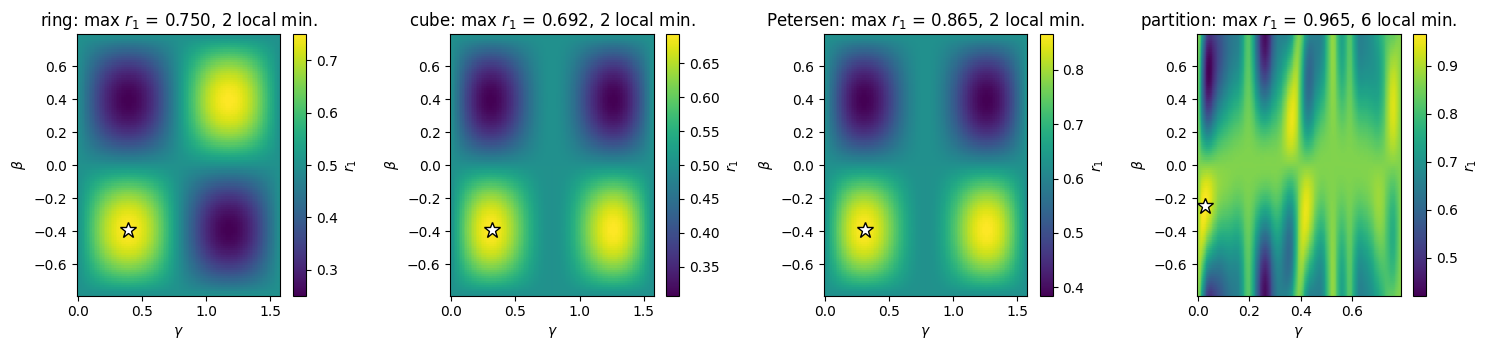

ring     : strict local minima of E_1 on the grid = 2, best p = 1 score = 0.7500
cube     : strict local minima of E_1 on the grid = 2, best p = 1 score = 0.6924
Petersen : strict local minima of E_1 on the grid = 2, best p = 1 score = 0.8654
partition: strict local minima of E_1 on the grid = 6, best p = 1 score = 0.9652


In [12]:
# ==============================================================================
# STEP 8: depth-one landscapes and their local minima
# ==============================================================================
GAMMAS_NP = jnp.linspace(0.0, jnp.pi / 4, 241)
P1_GRID["partition"] = np.asarray(landscape_p1(INSTANCES["partition"]["diag"], BETAS, GAMMAS_NP))
ib, ig = np.unravel_index(np.argmin(P1_GRID["partition"]), P1_GRID["partition"].shape)
INSTANCES["partition"]["p1_start"] = jnp.array([GAMMAS_NP[ig], BETAS[ib]])


def count_local_minima(grid):
    """Strict local minima of a 2D grid (8 neighbours), periodic in the first axis (beta), interior in the second.

    A point counts only if it is lower than every neighbour by more than 1e-9 of the grid's range, so that round-off
    on flat lines (e.g. beta = 0, where E_1 = 0 for every gamma) does not create spurious minima.
    """
    margin = 1e-9 * (grid.max() - grid.min())
    g = grid[:-1]                                                     # beta = +pi/4 duplicates beta = -pi/4
    core = g[:, 1:-1]
    is_min = np.ones_like(core, dtype=bool)
    for db in (-1, 0, 1):
        for dg in (-1, 0, 1):
            if db == 0 and dg == 0:
                continue
            shifted = np.roll(g, -db, axis=0)[:, 1 + dg:g.shape[1] - 1 + dg]
            is_min &= core < shifted - margin
    return int(is_min.sum())


fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, name in zip(axes, ["ring", "cube", "Petersen", "partition"]):
    inst = INSTANCES[name]
    gammas = GAMMAS_NP if name == "partition" else GAMMAS_MC
    grid = P1_GRID[name]
    r_grid = score(grid, inst)
    im = ax.pcolormesh(np.asarray(gammas), np.asarray(BETAS), r_grid, cmap="viridis", shading="auto")
    ib, ig = np.unravel_index(np.argmin(grid), grid.shape)
    ax.plot(float(gammas[ig]), float(BETAS[ib]), "*", color="white", ms=12, mec="k")
    n_min = count_local_minima(grid)
    inst["n_local_min_p1"] = n_min
    ax.set_title(f"{name}: max $r_1$ = {r_grid.max():.3f}, {n_min} local min.")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel(r"$\beta$")
    ax.grid(False)
    fig.colorbar(im, ax=ax, label=r"$r_1$")
fig.tight_layout()
plt.show()
for name in ["ring", "cube", "Petersen", "partition"]:
    print(f"{name:9s}: strict local minima of E_1 on the grid = {INSTANCES[name]['n_local_min_p1']}, "
          f"best p = 1 score = {score(P1_GRID[name].min(), INSTANCES[name]):.4f}")

The three MaxCut landscapes are smooth and have two grid minima each, of equal depth (bright, since the panels show the
score $r_1$, which is largest where $E_1$ is lowest): the white star and a second valley near $\gamma=\pi/2-\gamma^\ast$. Eq. (16) explains the second one. On a triangle-free $D$-regular graph $E_1$
depends on $\gamma$ through $\sin2\gamma\cos^{D-1}2\gamma$, and $\gamma\to\pi/2-\gamma$ maps this function to
$(-1)^{D-1}$ times itself: for $D=3$ the copy sits at the same $\beta$, for the ring at the opposite $\beta$, as the
figure shows. All three landscapes have the product form $\sin4\beta\cdot g(\gamma)$ of Section 5.3. The cube and the
Petersen graph share $D=3$, so their energies per edge are the same function and the two panels differ only in the
normalisation of $r_1$; the ring has $g(\gamma)\propto\sin2\gamma\cos2\gamma$ and a different shape.

The partition landscape has six grid minima, arranged in bands along $\gamma$. Its cost spectrum contains many
distinct eigenvalue differences, each contributing its own frequency in $\gamma$, and an optimiser started at random
ends in one of several valleys. Its best score at $p=1$ is $0.965$, high for the reason given in Section 3.5: the
score is measured relative to $E_{\max}=124$, far above the typical cost.

## 7. Gradients

### 7.1 Automatic differentiation

In simulation, `jax.grad(qaoa_energy)` differentiates through the `lax.scan` of Section 4 in reverse mode, at the cost
of a few energy evaluations, whatever $p$ is ([notebook 40](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb),
Section 10). On a quantum computer, gradients must be measured, and the standard tool is the parameter-shift rule.

### 7.2 The parameter-shift rule for a parameter that feeds many gates

For a single gate $e^{-i\theta P/2}$ with $P^2=\mathbb 1$ the energy is a sinusoid $a+b\cos\theta+c\sin\theta$ in
$\theta$, and $\partial_\theta E=[E(\theta+\pi/2)-E(\theta-\pi/2)]/2$ exactly (notebook 40, Section 8). A QAOA angle
is not of this kind. $\beta_l$ multiplies $B=\sum_qX_q$, whose eigenvalues are $-N,-N+2,\dots,N$, and $\gamma_l$
multiplies $H_C$, whose eigenvalues span $[E_{\min},E_{\max}]$. Writing $U_B(\beta)=\sum_\mu e^{-i\beta\mu}\Pi_\mu$ with
spectral projectors $\Pi_\mu$, the energy as a function of $\beta_l$ alone is, with coefficients $a_{\mu\nu}$ that do
not depend on $\beta_l$,

$$E(\beta_l)=\sum_{\mu,\nu}e^{-i\beta_l(\mu-\nu)}\,a_{\mu\nu}, \tag{18}$$

a trigonometric polynomial whose frequencies are the differences of eigenvalues of the generator: $2,4,\dots,2N$ for
$\beta_l$, and $2,4,\dots,E_{\max}-E_{\min}$ for $\gamma_l$ on a MaxCut instance. The two-term rule is exact only for
a single frequency. Applied to a whole layer, as $\partial_{\beta_l}E\approx E(\beta_l+\pi/4)-E(\beta_l-\pi/4)$ (exact
for $e^{-i\beta P}$ with a single Pauli string $P$; the shift $\pm\pi/4$ of $\beta_l$ is the $\pm\pi/2$ shift of the
angle $2\beta_l$ of every $R_x(2\beta_l)$ at once), and likewise for $\gamma_l$, it returns wrong numbers.

Two exact alternatives exist. The **gate-level rule** treats every gate as having its own angle: $\gamma_l$ enters
the $\vert E\vert$ gates $R_{ZZ}(\varphi_{l,e})$ with $\varphi_{l,e}=2\gamma_lJ_e$, and $\beta_l$ enters the $N$ gates
$R_x(\theta_{l,q})$ with $\theta_{l,q}=2\beta_l$. The chain rule gives

$$\frac{\partial E}{\partial\gamma_l}=\sum_e2J_e\frac{\partial E}{\partial\varphi_{l,e}},\qquad\frac{\partial E}{\partial\beta_l}=\sum_q2\,\frac{\partial E}{\partial\theta_{l,q}}, \tag{19}$$

and each partial derivative is a two-term shift of a single gate: $2p(\vert E\vert+N)$ circuit evaluations for the
full gradient. The **general shift rule** of Wierichs, Izaac, Wang and Lin (2022) instead uses the trigonometric
polynomial of Eq. (18) directly: with $R$ distinct frequencies, $2R$ evaluations per parameter suffice. The cell
measures the number of frequencies by a discrete Fourier transform of $E(\beta_1)$ and $E(\gamma_1)$, then compares
the gate-level rule (with the engine's `parameter_shift_grad`) and the layer-level two-term rule against automatic
differentiation, on the Petersen graph at $p=2$.

In [13]:
# ==============================================================================
# STEP 9: gradients on the Petersen graph at p = 2 -- AD, gate-level shift, layer-level two-term shift
# ==============================================================================
inst = INSTANCES["Petersen"]
N_G, P_G = inst["N"], 2
EDGES_G = list(inst["couplings"])
J_G = jnp.array([inst["couplings"][e] for e in EDGES_G])
diag_G = inst["diag"]
params_G = jnp.array([0.31, 0.52, -0.27, -0.13])                     # (gamma_1, gamma_2, beta_1, beta_2)


def energy_gate_angles(angles):
    """E as a function of one angle PER GATE: phi[l, e] of Rzz on edge e, theta[l, q] of Rx on qubit q (Eq. 19)."""
    n_e = len(EDGES_G)
    phi = angles[:P_G * n_e].reshape(P_G, n_e)
    theta = angles[P_G * n_e:].reshape(P_G, N_G)
    psi = product_state("+" * N_G)
    for l in range(P_G):
        for k, (i, j) in enumerate(EDGES_G):
            psi = apply_gate(psi, rzz(phi[l, k]), [i, j])
        for q in range(N_G):
            psi = apply_gate(psi, rx(theta[l, q]), [q])
    return jnp.sum(jnp.abs(psi) ** 2 * diag_G)


def layer_to_gate_angles(params):
    """phi[l, e] = 2 gamma_l J_e, theta[l, q] = 2 beta_l, flattened in the order used by `energy_gate_angles`."""
    g, b = params[:P_G], params[P_G:]
    return jnp.concatenate([(2 * g[:, None] * J_G[None, :]).reshape(-1), jnp.repeat(2 * b, N_G)])


g_ad = jax.grad(qaoa_energy)(params_G, diag_G)
angles_G = layer_to_gate_angles(params_G)
assert abs(float(energy_gate_angles(angles_G) - qaoa_energy(params_G, diag_G))) < TOL
g_gates = parameter_shift_grad(jax.jit(energy_gate_angles), angles_G)          # one derivative per gate
n_e = len(EDGES_G)
g_gamma = (2 * g_gates[:P_G * n_e].reshape(P_G, n_e) * J_G[None, :]).sum(axis=1)  # chain rule, Eq. (19)
g_beta = (2 * g_gates[P_G * n_e:].reshape(P_G, N_G)).sum(axis=1)
g_shift_gates = jnp.concatenate([g_gamma, g_beta])
E_fn = jax.jit(lambda t: qaoa_energy(t, diag_G))
eye = jnp.eye(2 * P_G)
g_layer = jnp.array([E_fn(params_G + jnp.pi / 4 * eye[k]) - E_fn(params_G - jnp.pi / 4 * eye[k]) for k in range(2 * P_G)])

print("component       :   gamma_1    gamma_2     beta_1     beta_2")
print("autodiff        : " + " ".join(f"{x:10.6f}" for x in np.asarray(g_ad)))
print("gate-level shift: " + " ".join(f"{x:10.6f}" for x in np.asarray(g_shift_gates)))
print("layer two-term  : " + " ".join(f"{x:10.6f}" for x in np.asarray(g_layer)))
err_gates, err_layer = max_abs(g_shift_gates - g_ad), max_abs(g_layer - g_ad)
print(f"max error: gate-level {err_gates:.2e} ({2 * P_G * (n_e + N_G)} circuit evaluations), "
      f"layer two-term {err_layer:.3f} ({4 * P_G} evaluations)")
assert err_gates < TOL * 100 and err_layer > 1e-2

# --- Fourier content of E(beta_1) and E(gamma_1): which frequencies does Eq. (18) contain? -------------------------
M = 64
for label, idx, n_max in [("beta_1", P_G, N_G), ("beta_2", P_G + 1, N_G),
                          ("gamma_1", 0, int(inst["E_max"] - inst["E_min"]) // 2)]:
    xs = jnp.arange(M) * jnp.pi / M                                    # one period pi, M points
    vals = np.asarray(jax.vmap(lambda x: E_fn(params_G.at[idx].set(x)))(xs))
    coef = np.abs(np.fft.rfft(vals)) / M                               # harmonic k <-> frequency 2k in the angle
    present = [k for k in range(1, M // 2) if coef[k] > 1e-9]
    print(f"E({label}): non-zero harmonics k (frequency 2k) = {present};  largest possible k = {n_max}")
    assert max(present) <= n_max

# --- the last mixer angle has the single frequency 4: a two-term rule with shift pi/8 is exact for it -------------
e_last = eye[2 * P_G - 1]
g_last = 2 * (E_fn(params_G + jnp.pi / 8 * e_last) - E_fn(params_G - jnp.pi / 8 * e_last))
print(f"beta_{P_G}: 2 [E(beta + pi/8) - E(beta - pi/8)] = {float(g_last):.6f},  autodiff = {float(g_ad[-1]):.6f}")
assert abs(float(g_last - g_ad[-1])) < TOL * 100

component       :   gamma_1    gamma_2     beta_1     beta_2
autodiff        :   0.183412  -1.084802  14.454792  -0.428476
gate-level shift:   0.183412  -1.084802  14.454792  -0.428476
layer two-term  :  -5.449757  -0.245556  -0.000000   0.000000
max error: gate-level 1.38e-13 (100 circuit evaluations), layer two-term 14.455 (8 evaluations)


E(beta_1): non-zero harmonics k (frequency 2k) = [2, 4, 6];  largest possible k = 10
E(beta_2): non-zero harmonics k (frequency 2k) = [2];  largest possible k = 10
E(gamma_1): non-zero harmonics k (frequency 2k) = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12];  largest possible k = 12
beta_2: 2 [E(beta + pi/8) - E(beta - pi/8)] = -0.428476,  autodiff = -0.428476


The gate-level rule reproduces automatic differentiation to $10^{-13}$ with $2p(\vert E\vert+N)=100$ circuit
evaluations. The two-term rule applied to whole layers uses 8 evaluations and is wrong in every component. Its
$\gamma$-components ($-5.45$ and $-0.25$) bear no resemblance to the true values ($0.18$ and $-1.08$), and its
$\beta$-components are exactly zero, whatever the true gradient (here $14.45$ and $-0.43$): a shift of $\pm\pi/4$ moves
$\beta_l$ to two points one period $\pi/2$ apart, where the energy is the same.

The Fourier analysis shows what an exact rule must handle. The spectrum of $B$ and the spin-flip symmetry allow, for
a mixer angle, only even harmonics $k=2,4,\dots,10$: in the symmetric sector the eigenvalues $N-2m$ of $B$ have even $m$
and differ by multiples of 4. For $E(\gamma_1)$ all twelve harmonics allowed by $E_{\max}-E_{\min}=24$ are present.

The mixer angles carry fewer harmonics than allowed, and the light cone of Section 5.1 explains how many. Each
rotation $e^{-i\beta X_q}$ that acts non-trivially on an operator contributes at most the harmonic $k=1$, so $E(\beta_l)$
contains harmonics up to the number of qubits on which the operator $Z_uZ_v$, propagated back through layers
$p,\dots,l+1$, is supported. For $\beta_2=\beta_p$ that operator is $Z_uZ_v$ itself, two qubits: only $k=2$ appears.
For $\beta_1$ it has passed one cost layer and lives on $u$, $v$ and their four other neighbours, six qubits on a
3-regular graph: $k\leq6$, as observed. A last-layer mixer angle therefore has the single frequency 4,
$E(\beta_p)=a+b\cos4\beta_p+c\sin4\beta_p$, and the two-term rule
$\partial_{\beta_p}E=2\,[E(\beta_p+\pi/8)-E(\beta_p-\pi/8)]$ with the shift $\pi/8$ is exact, as the last printed
line confirms. A general shift rule that uses the frequencies known in advance needs $2\times5=10$ evaluations for a
mixer angle in general, three frequencies (six evaluations) for $\beta_1$ here, one (two evaluations) for $\beta_p$, and
$2\times12=24$ for $\gamma_1$. The gate-level rule needs $2N=20$ per $\beta_l$ and $2\vert E\vert=30$ per $\gamma_l$.

> **Common pitfall.** A QAOA angle controls many gates at once. The rule "two circuit evaluations with shifts
> $\pm\pi/2$ of the gate angle" holds for a parameter that sits in one Pauli rotation; applied to $\beta_l$ and $\gamma_l$
> it gives a wrong gradient. Either shift every gate separately and add the results with the chain rule, or use a shift
> rule built for the frequencies that $E$ actually contains.

## 8. Optimising deeper circuits

### 8.1 Two initialisation strategies

The landscape at $p>1$ has $2p$ dimensions and, as the partition instance already showed at $p=1$, may have many local
minima. We compare two ways of starting Adam (Kingma and Ba, 2014;
[notebook 41](../ch11_variational_quantum_circuits/41_optimizers.ipynb)):

* **random restarts**: $R$ independent starts with angles drawn uniformly, all optimised in parallel (`vmap` over the
  compiled `lax.scan` loop), keeping the best;
* **interpolation** (INTERP of Zhou, Wang, Choi, Pichler and Lukin, 2020): start at $p=1$ from the grid optimum of
  Section 5, and initialise depth $p+1$ from the optimum $(\boldsymbol\gamma^{(p)},\boldsymbol\beta^{(p)})$ at depth
  $p$ by linear interpolation,

$$\gamma_i^{(p+1),\rm init}=\frac{i-1}{p}\,\gamma_{i-1}^{(p)}+\frac{p-i+1}{p}\,\gamma_i^{(p)},\qquad i=1,\dots,p+1,\qquad\gamma_0^{(p)}=\gamma_{p+1}^{(p)}=0, \tag{20}$$

and the same for $\boldsymbol\beta$. The interpolated schedule has the same shape as the old one, stretched over one
more layer, so the optimiser starts close to a good minimum. A single optimisation per depth is run.

Every run uses Adam with $300$ steps. The learning rate is $0.05$ for the MaxCut instances and $0.01$ for the
partition instance, whose landscape varies much faster in $\gamma$; random initial angles are drawn from
$[-\pi/4,\pi/4]$ for $\beta$ and from one $\gamma$-period ($[-\pi/2,\pi/2]$ for MaxCut, $[-\pi/4,\pi/4]$ for the
partition).

In [14]:
# ==============================================================================
# STEP 10: Adam in lax.scan, INTERP, and random restarts
# ==============================================================================
def train_adam(params0, diag, lr, n_steps):
    """Minimise E_p with Adam for n_steps (engine `adam_init` / `adam_update`), compiled as ONE lax.scan.

    Returns (final params, final energy, energy history).
    JAX   the step counter t lives in Adam's state; scan carries it as an integer array.  vmap over params0 runs
          many random starts in one compiled program.
    """
    vg = jax.value_and_grad(qaoa_energy)

    def body(carry, _):
        params, state = carry
        E, g = vg(params, diag)
        params, state = adam_update(params, g, state, lr=lr)
        return (params, state), E

    m, v, _ = adam_init(params0)
    (params, _), hist = lax.scan(body, (params0, (m, v, jnp.asarray(0))), None, length=n_steps)
    return params, qaoa_energy(params, diag), hist


train_one = jax.jit(train_adam, static_argnums=3)
train_many = jax.jit(jax.vmap(train_adam, in_axes=(0, None, None, None)), static_argnums=3)


def interp_init(params):
    """INTERP, Eq. (20): depth-p optimum -> depth-(p+1) starting point (gamma and beta interpolated separately)."""
    params = np.asarray(params)
    p = params.size // 2

    def stretch(x):
        xp = np.concatenate([[0.0], x, [0.0]])
        i = np.arange(1, p + 2)
        return (i - 1) / p * xp[i - 1] + (p - i + 1) / p * xp[i]

    return jnp.asarray(np.concatenate([stretch(params[:p]), stretch(params[p:])]), dtype=RDTYPE)


def canonical(params, maxcut):
    """Map angles into the fundamental domain of Section 4.3: beta_l into [-pi/4, pi/4), gamma_l into one period
    centred on zero, then apply time reversal so that sum(gamma) >= 0.  The state changes only by a global phase."""
    params = np.asarray(params, dtype=float).copy()
    p = params.size // 2
    period = np.pi if maxcut else np.pi / 2
    params[:p] = (params[:p] + period / 2) % period - period / 2
    params[p:] = (params[p:] + np.pi / 4) % (np.pi / 2) - np.pi / 4
    return -params if params[:p].sum() < 0 else params


P_MAX, N_STEPS, N_RESTARTS = 6, 300, 12
LR = {"ring": 0.05, "cube": 0.05, "Petersen": 0.05, "partition": 0.01}
RESULTS = {}
t_start = time.perf_counter()
for name, inst in INSTANCES.items():
    res = dict(r_interp=[], p_interp=[], params_interp=[], r_best=[], r_median=[], p_best=[])
    params = None
    for p in range(1, P_MAX + 1):
        # --- INTERP ---------------------------------------------------------------------------------------
        start = inst["p1_start"] if p == 1 else interp_init(params)
        params, E, _ = train_one(start, inst["diag"], LR[name], N_STEPS)
        res["r_interp"].append(score(float(E), inst))
        res["p_interp"].append(float(p_optimal(params, inst["diag"], inst["optimal"])))
        res["params_interp"].append(canonical(params, inst["maxcut"]))
        # --- random restarts (only where they are informative and affordable) -----------------------------
        if name in ("Petersen", "partition"):
            k1, k2 = jax.random.split(jax.random.PRNGKey(100 + p))
            g_half = jnp.pi / 2 if inst["maxcut"] else jnp.pi / 4
            g0 = jax.random.uniform(k1, (N_RESTARTS, p), minval=-g_half, maxval=g_half)
            b0 = jax.random.uniform(k2, (N_RESTARTS, p), minval=-jnp.pi / 4, maxval=jnp.pi / 4)
            th, Es, _ = train_many(jnp.concatenate([g0, b0], axis=1), inst["diag"], LR[name], N_STEPS)
            rs = score(np.asarray(Es), inst)
            res["r_best"].append(float(rs.max()))
            res["r_median"].append(float(np.median(rs)))
            res["p_best"].append(float(p_optimal(th[int(np.argmax(rs))], inst["diag"], inst["optimal"])))
    RESULTS[name] = res
print(f"training time (all instances, p = 1..{P_MAX}): {time.perf_counter() - t_start:.1f} s")

print(f"\n{'':10s}" + "".join(f"{'p=' + str(p):>9s}" for p in range(1, P_MAX + 1)))
for name, res in RESULTS.items():
    print(f"{name:10s}" + "".join(f"{x:9.4f}" for x in res["r_interp"]) + "   r_p, INTERP")
    print(f"{'':10s}" + "".join(f"{x:9.4f}" for x in res["p_interp"]) + "   p_opt, INTERP")
    if res["r_best"]:
        print(f"{'':10s}" + "".join(f"{x:9.4f}" for x in res["r_best"]) + f"   r_p, best of {N_RESTARTS} random starts")
        print(f"{'':10s}" + "".join(f"{x:9.4f}" for x in res["r_median"]) + f"   r_p, median of {N_RESTARTS} random starts")
        print(f"{'':10s}" + "".join(f"{x:9.4f}" for x in res["p_best"]) + "   p_opt, best random start")

training time (all instances, p = 1..6): 41.1 s

                p=1      p=2      p=3      p=4      p=5      p=6
ring         0.7500   0.8333   0.8750   1.0000   1.0000   1.0000   r_p, INTERP
             0.1486   0.3608   0.5381   1.0000   1.0000   1.0000   p_opt, INTERP
cube         0.6925   0.8079   0.9460   0.9861   0.9972   0.9994   r_p, INTERP
             0.1863   0.5207   0.8716   0.9720   0.9936   0.9986   p_opt, INTERP
Petersen     0.8656   0.9254   0.9770   0.9947   0.9974   0.9994   r_p, INTERP
             0.1682   0.4490   0.8438   0.9767   0.9872   0.9984   p_opt, INTERP
             0.8656   0.9254   0.9770   0.9947   0.9988   0.9991   r_p, best of 12 random starts
             0.8656   0.9178   0.9518   0.9812   0.9913   0.9957   r_p, median of 12 random starts
             0.1682   0.4490   0.8438   0.9767   0.9961   0.9971   p_opt, best random start
partition    0.9654   0.9797   0.9857   0.9871   0.9933   0.9954   r_p, INTERP
             0.3731   0.4796   0.5394  

The table lists the score and the probability of the optimum for every instance and depth; the figure shows the same
numbers, together with the random-guessing scores and the values $(2p+1)/(2p+2)$.

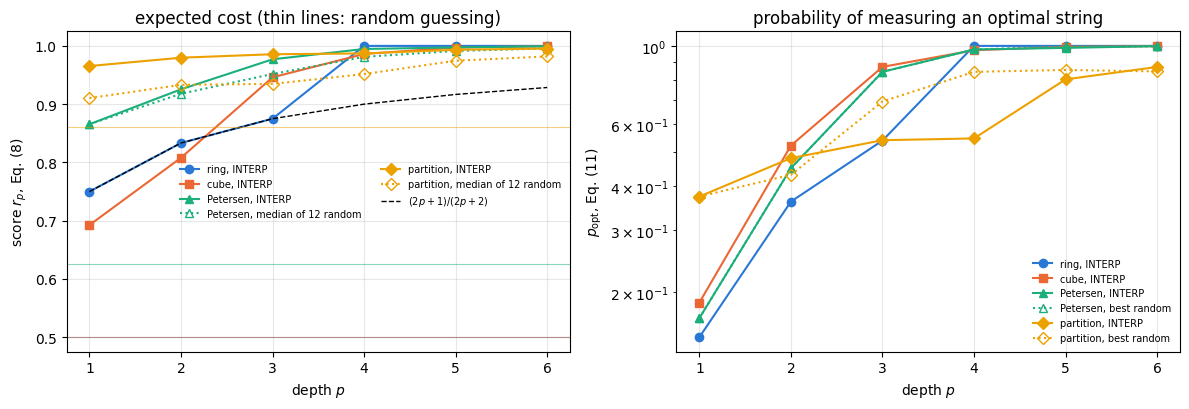

ring, p = 1..3: max |r_p - (2p+1)/(2p+2)| = 2.4e-15;  p = 4: r = 1.000000


In [15]:
# ==============================================================================
# STEP 11: approximation ratio and probability of the optimum versus depth
# ==============================================================================
ps = np.arange(1, P_MAX + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
for c, (name, res) in enumerate(RESULTS.items()):
    ax1.plot(ps, res["r_interp"], "-" + MARKERS[c], color=PALETTE[c], label=f"{name}, INTERP")
    ax2.plot(ps, res["p_interp"], "-" + MARKERS[c], color=PALETTE[c], label=f"{name}, INTERP")
    if res["r_best"]:
        ax1.plot(ps, res["r_median"], ":" + MARKERS[c], color=PALETTE[c], mfc="none",
                 label=f"{name}, median of {N_RESTARTS} random")
        ax2.plot(ps, res["p_best"], ":" + MARKERS[c], color=PALETTE[c], mfc="none", label=f"{name}, best random")
ax1.plot(ps, (2 * ps + 1) / (2 * ps + 2), "k--", lw=1, label=r"$(2p+1)/(2p+2)$")
for c, name in enumerate(INSTANCES):
    ax1.axhline(INSTANCES[name]["r_random"], color=PALETTE[c], lw=0.8, alpha=0.5)
ax1.set_xlabel("depth $p$")
ax1.set_ylabel("score $r_p$, Eq. (8)")
ax1.set_title("expected cost (thin lines: random guessing)")
ax1.legend(fontsize=7, ncol=2)
ax2.set_xlabel("depth $p$")
ax2.set_ylabel(r"$p_{\rm opt}$, Eq. (11)")
ax2.set_title("probability of measuring an optimal string")
ax2.set_yscale("log")
ax2.legend(fontsize=7)
fig.tight_layout()
plt.show()

# --- checks: ring values (2p+1)/(2p+2) while the light cone is open, 1 once it closes ------------------------------
r_ring = np.array(RESULTS["ring"]["r_interp"])
err_ring = np.max(np.abs(r_ring[:3] - (2 * ps[:3] + 1) / (2 * ps[:3] + 2)))
print(f"ring, p = 1..3: max |r_p - (2p+1)/(2p+2)| = {err_ring:.1e};  p = 4: r = {r_ring[3]:.6f}")
assert err_ring < 1e3 * TOL and r_ring[3] > 0.9999
assert all(np.all(np.diff(RESULTS[n]["r_interp"]) > -1e-3) for n in RESULTS)  # INTERP never loses at the next depth

**The ring.** The INTERP optima give $r_p=3/4,\,5/6,\,7/8$ at $p=1,2,3$ to round-off and $r_4=1$: the depth-four
circuit prepares an optimal state exactly, and $p_{\rm opt}$ jumps from $0.54$ to $1$. Farhi *et al.* (2014) found
$(2p+1)/(2p+2)$ numerically on rings with $p<N/2$, and Mbeng, Fazio and Santoro (2019) proved that on an even ring the
residual $1-r_p$ is at least $1/(2p+2)$ for $2p<N$ and showed that it drops to zero for $2p\geq N$. The light cone
explains the switch. For $p<N/2$ every edge sees an open segment of $2p+2$ spins, the same as on an infinite chain; at $p=N/2=4$
the light cone closes around the ring.

**The 3-regular graphs.** The score rises from $0.6925$ (cube) and $0.8656$ (Petersen) at $p=1$ to $0.9994$ for both
at $p=6$, and $p_{\rm opt}$ from $0.19$ and $0.17$ to $0.97$ and $0.98$ at $p=4$. At $p=1$ the cube's score exceeds
random guessing by $0.19$, while greedy descent from a random start averages $0.96$.

**Random restarts against INTERP.** On the Petersen graph the best of 12 random starts agrees with INTERP to four
digits for $p\leq4$, is better at $p=5$ ($0.9988$ against $0.9974$) and slightly worse at $p=6$ ($0.9991$ against
$0.9994$); the median start trails INTERP by up to $0.025$ (at $p=3$). On the partition instance INTERP is better at
$p=2,3,6$, the best random start at $p=4$ ($0.9890$ against $0.9871$), and the two agree to $10^{-4}$ at $p=1,5$. One
INTERP run per depth costs a twelfth of the restarts. INTERP follows a single branch of local optima from depth to
depth, and nothing guarantees that this branch contains the global optimum: on the partition instance its gain from
$p=3$ to $p=4$ is only $0.0014$, while a random start at $p=4$ does better. These are single instances with a fixed
budget of 300 Adam steps. Zhou *et al.* (2020) report, for MaxCut on larger graphs, that random initialisation needs
a number of starts growing exponentially with $p$ to match their heuristic initialisations.

**Expected cost and the probability of the optimum are different figures of merit.** At $p=4$ the INTERP states of
the partition instance and of the cube have almost the same score ($0.9871$ and $0.9861$), but $p_{\rm opt}=0.55$
against $0.97$. On the partition instance itself, the best random start at $p=3$ has a lower score than INTERP
($0.9737$ against $0.9857$) and a higher $p_{\rm opt}$ ($0.69$ against $0.54$). The score of the partition instance is
measured relative to $E_{\max}=124$, so a state with most of its weight on imbalance 2 (cost $-16$, against $-20$ for
a perfect split) already scores close to one. A good score means a low *average* cost and does not require weight on
the optimal strings.

### 8.2 The shape of the optimal schedules

The cell plots the INTERP optima at $p=6$ against the layer position $(l-\tfrac12)/p$, after mapping each angle into
the fundamental domain (Section 4.3).

ring      gamma = [0.182 0.591 0.748 0.527 0.413 0.572]   beta = [-0.572 -0.413 -0.527 -0.748 -0.591 -0.182]
cube      gamma = [0.113 0.245 0.273 0.285 0.338 0.402]   beta = [-0.639 -0.525 -0.476 -0.478 -0.387 -0.172]
Petersen  gamma = [0.138 0.303 0.395 0.48  0.547 0.521]   beta = [-0.579 -0.424 -0.305 -0.217 -0.189 -0.107]
partition gamma = [0.018 0.044 0.025 0.097 0.105 0.255]   beta = [-0.38  -0.159 -0.074 -0.008 -0.083 -0.133]


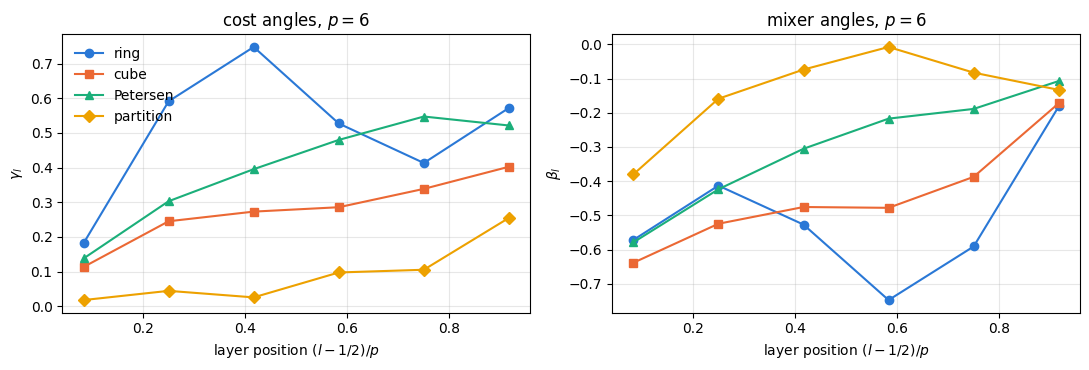

In [16]:
# ==============================================================================
# STEP 12: optimal angles at p = 6 versus layer position
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
x = (np.arange(1, P_MAX + 1) - 0.5) / P_MAX
for c, (name, res) in enumerate(RESULTS.items()):
    th = res["params_interp"][-1]
    ax1.plot(x, th[:P_MAX], "-" + MARKERS[c], color=PALETTE[c], label=name)
    ax2.plot(x, th[P_MAX:], "-" + MARKERS[c], color=PALETTE[c], label=name)
    print(f"{name:9s} gamma = {np.round(th[:P_MAX], 3)}   beta = {np.round(th[P_MAX:], 3)}")
ax1.set_xlabel(r"layer position $(l-1/2)/p$")
ax1.set_ylabel(r"$\gamma_l$")
ax1.set_title(r"cost angles, $p=6$")
ax2.set_xlabel(r"layer position $(l-1/2)/p$")
ax2.set_ylabel(r"$\beta_l$")
ax2.set_title(r"mixer angles, $p=6$")
ax1.legend()
fig.tight_layout()
plt.show()
for name in ["cube", "Petersen"]:
    th = RESULTS[name]["params_interp"][-1]
    assert th[P_MAX - 1] > th[0] and np.all(th[P_MAX:] < 0) and abs(th[-1]) < abs(th[P_MAX])   # annealing-like ends

On the cube the optimal $\gamma_l$ rise monotonically from $0.113$ to $0.402$ and $\vert\beta_l\vert$ falls from $0.639$
to $0.172$ (with one near-tie, $0.476$ and $0.478$). On the Petersen graph $\gamma_l$ rises from $0.138$ to $0.547$ at
$l=5$ and drops slightly to $0.521$ in the last layer, while $\vert\beta_l\vert$ falls monotonically from $0.579$ to
$0.107$. All $\beta_l$ are negative and all $\gamma_l$ positive. The circuit starts with mostly mixing and ends with
mostly cost evolution. Zhou *et al.* (2020) observed the same smooth pattern on many MaxCut instances, and it is the
reason why the interpolation of Eq. (20) gives good starting points. The ring's optimum at $p=6$ is of a different kind,
mirror-symmetric with $\beta_l=-\gamma_{p+1-l}$ to the printed precision; from $p=4$ on the ring is solved exactly and the
optimum is not unique. The partition schedule has much smaller $\gamma_l$ (between $0.018$ and $0.255$; the couplings
reach 8), rising except for a dip at $l=3$, and negative $\beta_l$ without a monotone pattern. The pattern on the 3-regular graphs is that of an annealing schedule, which the next
section makes precise.

## 9. The annealing limit

### 9.1 Trotterised annealing is a QAOA circuit

Adiabatic quantum computing (Farhi, Goldstone, Gutmann and Sipser, 2000) prepares the ground state of $H_C$ by slowly
changing the Hamiltonian

$$H(s)=(1-s)\,H_{\rm init}+s\,H_C,\qquad H_{\rm init}=-B=-\sum_qX_q,\qquad s:0\to1,$$

starting in the ground state $\vert+\rangle^{\otimes N}$ of $H_{\rm init}$. If the total time $T$ is long compared
with $1/\Delta_{\min}^2$, where $\Delta_{\min}$ is the smallest gap above the ground level along the path (in the
spin-flip-symmetric sector, which the evolution never leaves), the state follows the instantaneous ground state. Split the
total time $T$ into $p$ steps of length $\Delta t=T/p$ and evaluate $s$ at the midpoint of each step,
$s_l=(l-\tfrac12)/p$. A first-order Trotter step ([notebook 12](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb)) is

$$e^{-i\Delta t\,H(s_l)}\approx e^{-i\Delta t(1-s_l)H_{\rm init}}\,e^{-i\Delta t\,s_lH_C}=e^{+i(1-s_l)\Delta t\,B}\,e^{-is_l\Delta t\,H_C}=U_B(\beta_l)\,U_C(\gamma_l),$$

with

$$\gamma_l=s_l\,\Delta t,\qquad\beta_l=-(1-s_l)\,\Delta t. \tag{21}$$

This is a QAOA circuit with a fixed linear schedule. The minus sign of $\beta_l$ comes from $H_{\rm init}=-B$; it
matches the relative sign of the optimised schedules of Section 8.2 ($\gamma_l>0$, $\beta_l<0$). As $p\to\infty$ at
fixed $\Delta t$ the total time $T=p\,\Delta t$ grows without bound, while $s$ changes by only $1/p$ per step. By
the Baker–Campbell–Hausdorff formula each step equals $e^{-i\Delta t\,H_{\rm eff}(s_l)}$ with
$H_{\rm eff}(s)=H(s)+O(\Delta t)$, and $H_{\rm eff}=H$ at $s=0$ and $s=1$, where one of the two terms vanishes. For
$\Delta t$ small enough that this correction does not close the gap, the adiabatic theorem applied to $H_{\rm eff}$
drives the state into the ground level of $H_C$. The optimal QAOA energy at depth $p$ is at most that of any fixed
schedule, so $r_p\to1$ as $p\to\infty$.

The cell evaluates the linear schedule on the Petersen graph for three step lengths and $p$ up to 128, and compares it
with the optimised circuits of Section 8. As a wrong control, the schedule with the sign of $\beta$ reversed is
Trotterised annealing of $+B$, whose *highest* state is $\vert+\rangle^{\otimes N}$: it must drive the system towards
the top of the spectrum.

dt = 0.2: r_p = [0.6714 0.6988 0.7731 0.8877 0.9646 0.9947 0.9991 0.9999]
         p_opt = [0.018  0.0251 0.0566 0.2156 0.6283 0.9406 0.9894 0.9987]


dt = 0.4: r_p = [0.7731 0.8153 0.9028 0.9674 0.9953 0.9991 0.9999 1.    ]
         p_opt = [0.0536 0.0901 0.2696 0.6498 0.9468 0.9893 0.9988 0.9998]


dt = 0.6: r_p = [0.8491 0.8762 0.9527 0.9873 0.9991 1.     1.     1.    ]
         p_opt = [0.124  0.2115 0.5198 0.8585 0.9899 0.9999 0.9998 0.9999]
wrong sign of beta, p = 64, dt = 0.4: r = 0.0096
p = 2: 1 - r, optimised = 0.0746;  best linear schedule = 0.1238;  ratio = 1.7
p = 4: 1 - r, optimised = 0.0053;  best linear schedule = 0.0473;  ratio = 8.9
smallest p of the dt = 0.6 schedule that reaches the optimised r_4 = 0.9947: p = 16


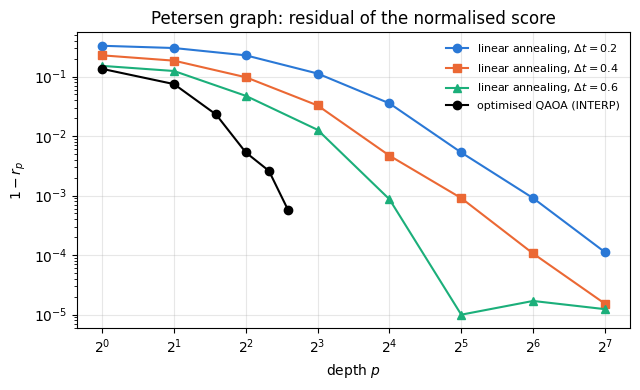

In [17]:
# ==============================================================================
# STEP 13: the linear annealing schedule, Eq. (21), on the Petersen graph
# ==============================================================================
def annealing_schedule(p, dt):
    """Eq. (21): first-order Trotterised linear annealing from -B to H_C as QAOA angles (gamma_1..p, beta_1..p)."""
    s = (np.arange(1, p + 1) - 0.5) / p
    return jnp.asarray(np.concatenate([s * dt, -(1 - s) * dt]), dtype=RDTYPE)


inst = INSTANCES["Petersen"]
P_ANNEAL = [1, 2, 4, 8, 16, 32, 64, 128]
DTS = [0.2, 0.4, 0.6]
anneal = {}
for dt in DTS:
    r_list, po_list = [], []
    for p in P_ANNEAL:
        th = annealing_schedule(p, dt)
        r_list.append(score(float(qaoa_energy(th, inst["diag"])), inst))
        po_list.append(float(p_optimal(th, inst["diag"], inst["optimal"])))
    anneal[dt] = (np.array(r_list), np.array(po_list))
    print(f"dt = {dt}: r_p = {np.round(r_list, 4)}")
    print(f"{'':9s}p_opt = {np.round(po_list, 4)}")
th_wrong = annealing_schedule(64, 0.4)
th_wrong = th_wrong.at[64:].multiply(-1.0)
r_wrong = score(float(qaoa_energy(th_wrong, inst["diag"])), inst)
print(f"wrong sign of beta, p = 64, dt = 0.4: r = {r_wrong:.4f}")
assert anneal[0.4][0][-1] > 0.999 and r_wrong < 0.05
r_opt = np.array(RESULTS["Petersen"]["r_interp"])
for p in (2, 4):
    best_lin = max(anneal[dt][0][P_ANNEAL.index(p)] for dt in DTS)
    print(f"p = {p}: 1 - r, optimised = {1 - r_opt[p - 1]:.4f};  best linear schedule = {1 - best_lin:.4f};  "
          f"ratio = {(1 - best_lin) / (1 - r_opt[p - 1]):.1f}")
p_lin = next(p for p in P_ANNEAL if anneal[0.6][0][P_ANNEAL.index(p)] >= r_opt[3])
print(f"smallest p of the dt = 0.6 schedule that reaches the optimised r_4 = {r_opt[3]:.4f}: p = {p_lin}")

fig, ax = plt.subplots(figsize=(6.5, 4))
for c, dt in enumerate(DTS):
    ax.semilogx(P_ANNEAL, 1 - anneal[dt][0], "-" + MARKERS[c], color=PALETTE[c], base=2,
                label=rf"linear annealing, $\Delta t={dt}$")
ax.semilogx(ps, 1 - np.array(RESULTS["Petersen"]["r_interp"]), "-o", color="k", base=2, label="optimised QAOA (INTERP)")
ax.set_yscale("log")
ax.set_xlabel("depth $p$")
ax.set_ylabel(r"$1-r_p$")
ax.set_title("Petersen graph: residual of the normalised score")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The linear schedule converges to the optimum as $p$ grows, and over this range the longest step converges fastest:
with $\Delta t=0.6$ it reaches $r=0.9991$ at $p=16$, with $\Delta t=0.4$ it needs $p=64$ for $r=0.9999$. (Longer
steps mean a longer total time $T=p\,\Delta t$, which the adiabatic condition rewards, at the price of a larger Trotter
error per step.) The optimised circuits need far fewer layers: at $p=4$ their residual $1-r_p=0.0053$ is $8.9$ times
smaller than that of the best linear schedule at the same depth, and the $\Delta t=0.6$ schedule needs $p=16$ to match
the optimised $r_4$. At $p=2$ the advantage is a factor $1.7$. The wrong-sign schedule ends at $r=0.0096$, near the
top of the spectrum, as predicted.

> **Physics insight.** Annealing guarantees $r_p\to1$ only for long times, set by the minimum gap of $H(s)$. Optimised
> angles may do better by using diabatic transitions; Zhou *et al.* (2020) study instances on which adiabatic annealing
> fails because of small gaps and QAOA does not.

## 10. Transferring angles between graphs

Eq. (17) showed that at $p=1$ the optimal angles on triangle-free $D$-regular graphs depend only on $D$. Brandão,
Broughton, Farhi, Gutmann and Neven (2018) showed more generally that for fixed angles the QAOA objective of MaxCut
concentrates: typical instances drawn from a reasonable distribution (they prove it for large 3-regular graphs at low
depth) give nearly the same value, and angles optimised on small instances work on larger ones. We test this on six
random connected 3-regular graphs with $N=10$, generated by random pairing of vertex "stubs" with rejection of loops,
double edges and disconnected graphs. The angles optimised on the Petersen graph (Section 8) are applied unchanged
and compared with each graph's own INTERP optimum.

In [18]:
# ==============================================================================
# STEP 14: transfer of optimised angles from the Petersen graph to random 3-regular graphs
# ==============================================================================
def random_regular_graph(N, D, rng):
    """Random simple connected D-regular graph by stub pairing with rejection (fine for N <= 10)."""
    while True:
        stubs = rng.permutation(np.repeat(np.arange(N), D)).reshape(-1, 2)
        edges = {(int(min(a, b)), int(max(a, b))) for a, b in stubs}
        if np.any(stubs[:, 0] == stubs[:, 1]) or len(edges) < len(stubs):
            continue
        nb, seen, stack = neighbours(N, edges), {0}, [0]
        while stack:
            for w in nb[stack.pop()]:
                if w not in seen:
                    seen.add(w)
                    stack.append(w)
        if len(seen) == N:
            return sorted(edges)


P_TRANSFER = 3
rng = np.random.default_rng(18)
source = [jnp.asarray(t) for t in RESULTS["Petersen"]["params_interp"][:P_TRANSFER]]
rows = []
for g in range(6):
    edges = random_regular_graph(10, 3, rng)
    diag = ising_diagonal(10, maxcut_couplings(edges))
    flat = np.asarray(diag).reshape(-1)
    tgt = dict(E_min=float(flat.min()), E_max=float(flat.max()))
    n_tri = sum(len(neighbours(10, edges)[u] & neighbours(10, edges)[v]) for u, v in edges) // 3
    r_tr, r_tr_opt, r_own = [], [], []
    grid = np.asarray(landscape_p1(diag, BETAS, GAMMAS_MC))
    ib, ig = np.unravel_index(np.argmin(grid), grid.shape)
    params = jnp.array([GAMMAS_MC[ig], BETAS[ib]])
    for p in range(1, P_TRANSFER + 1):
        r_tr.append(score(float(qaoa_energy(source[p - 1], diag)), tgt))            # transferred, no optimisation
        _, E_tr, _ = train_one(source[p - 1], diag, 0.05, N_STEPS)                   # transferred, then Adam
        r_tr_opt.append(score(float(E_tr), tgt))
        params, E, _ = train_one(params if p == 1 else interp_init(params), diag, 0.05, N_STEPS)   # own INTERP chain
        r_own.append(score(float(E), tgt))
    rows.append((n_tri, np.array(r_tr), np.array(r_tr_opt), np.array(r_own)))
    print(f"graph {g}: {n_tri} triangles, P_max = {(15 - tgt['E_min']) / 2:.0f}")
    print(f"    transferred        r_p = {np.round(r_tr, 4)}")
    print(f"    transferred + Adam r_p = {np.round(r_tr_opt, 4)}")
    print(f"    own INTERP chain   r_p = {np.round(r_own, 4)}")
best = np.array([np.maximum(o, t_opt) for _, _, t_opt, o in rows])            # best optimum found per graph and depth
loss = best - np.array([t for _, t, _, _ in rows])
print("loss of the transferred angles against the best optimum found, mean per depth:", np.round(loss.mean(axis=0), 4))
print("                                                                max per depth:", np.round(loss.max(axis=0), 4))
diff = np.array([t_opt - o for _, _, t_opt, o in rows])
print(f"transferred + Adam against the own INTERP chain, over {diff.size} (graph, depth) pairs: "
      f"same optimum (within 1e-4) {int(np.sum(np.abs(diff) < 1e-4))}, better {int(np.sum(diff >= 1e-4))}, "
      f"worse {int(np.sum(diff <= -1e-4))}")
assert np.all(loss > -1e-3)                                                    # optimising never loses against no optimising

graph 0: 3 triangles, P_max = 13
    transferred        r_p = [0.7605 0.8325 0.8724]
    transferred + Adam r_p = [0.7648 0.836  0.8841]
    own INTERP chain   r_p = [0.7648 0.836  0.8841]


graph 1: 2 triangles, P_max = 13
    transferred        r_p = [0.7733 0.8596 0.8839]
    transferred + Adam r_p = [0.7753 0.8832 0.9208]
    own INTERP chain   r_p = [0.7753 0.8832 0.9448]


graph 2: 4 triangles, P_max = 12
    transferred        r_p = [0.81   0.8822 0.9274]
    transferred + Adam r_p = [0.818  0.8926 0.9314]
    own INTERP chain   r_p = [0.818  0.8926 0.9314]


graph 3: 1 triangles, P_max = 13
    transferred        r_p = [0.7862 0.8704 0.9035]
    transferred + Adam r_p = [0.7866 0.8847 0.939 ]
    own INTERP chain   r_p = [0.7866 0.8847 0.939 ]


graph 4: 0 triangles, P_max = 13
    transferred        r_p = [0.799  0.8681 0.9095]
    transferred + Adam r_p = [0.799  0.872  0.9156]
    own INTERP chain   r_p = [0.799  0.872  0.9156]


graph 5: 0 triangles, P_max = 15
    transferred        r_p = [0.6925 0.7679 0.7764]
    transferred + Adam r_p = [0.6925 0.7918 0.8284]
    own INTERP chain   r_p = [0.6925 0.7918 0.878 ]
loss of the transferred angles against the best optimum found, mean per depth: [0.0024 0.0133 0.0367]
                                                                max per depth: [0.008  0.024  0.1016]
transferred + Adam against the own INTERP chain, over 18 (graph, depth) pairs: same optimum (within 1e-4) 16, better 0, worse 2


At $p=1$ the transferred angles lose at most $0.008$ in the score (mean $0.002$), with or without triangles: by
Eq. (16), a few triangles shift the depth-one optimum only slightly, and on the two triangle-free graphs (4 and 5)
Eq. (17) makes the transfer exact. The loss grows with depth, to a mean of $0.013$ at $p=2$ and $0.037$ at $p=3$, and it
is not ordered by the number of triangles: the largest loss, $0.10$ at $p=3$, occurs on graph 5, which has no triangles
but is bipartite ($P_{\max}=15$), unlike the Petersen graph. Starting Adam from the transferred angles reaches the same
optimum as the graph's own INTERP chain in 16 of the 18 cases and a worse one in the other two (graphs 1 and 5 at $p=3$).

At ten vertices "typical" instances in the sense of Brandão *et al.* do not exist yet: their concentration argument
concerns large graphs, in which short cycles are rare, whereas four of our six random graphs contain triangles. At
this size transferred angles are useful starting points for a local optimisation, and at
$p=1$ they are already close to optimal.

## 11. Sampling bit strings

### 11.1 The distribution of cut sizes

On hardware, the output of QAOA is a list of measured strings. The cell compares the distribution of the cut size $P$
under the optimised QAOA states on the Petersen graph with the distribution under uniformly random strings, checks that
a string and its mirror image (all bits flipped) have the same probability, as Section 4.3 requires, and shows the
same comparison for the imbalance $\vert\sum_in_iz_i\vert$ of the partition instance.

Petersen, p = 1: <P> = 10.387,  Prob(P = 12) = 0.1682,  Prob(P >= 11) = 0.5657
                  max |Prob(z) - Prob(all bits flipped)| = 0.0e+00
Petersen, p = 3: <P> = 11.724,  Prob(P = 12) = 0.8438,  Prob(P >= 11) = 0.9488
                  max |Prob(z) - Prob(all bits flipped)| = 0.0e+00


Petersen, p = 6: <P> = 11.993,  Prob(P = 12) = 0.9984,  Prob(P >= 11) = 0.9985
                  max |Prob(z) - Prob(all bits flipped)| = 0.0e+00
Petersen, uniform: <P> = 7.500,  Prob(P = 12) = 0.0098
partition, p = 1: Prob(imbalance 0, 2, 4) = [0.3731 0.4908 0.1212];  the 44 optimal strings have probabilities between 0.0085 and 0.0085
partition, p = 4: Prob(imbalance 0, 2, 4) = [0.5456 0.452  0.0021];  the 44 optimal strings have probabilities between 0.0121 and 0.0139


partition, p = 6: Prob(imbalance 0, 2, 4) = [0.8713 0.1219 0.0055];  the 44 optimal strings have probabilities between 0.0191 and 0.0228
partition, uniform: Prob(imbalance 0, 2, 4) = [0.1719 0.3125 0.2422]


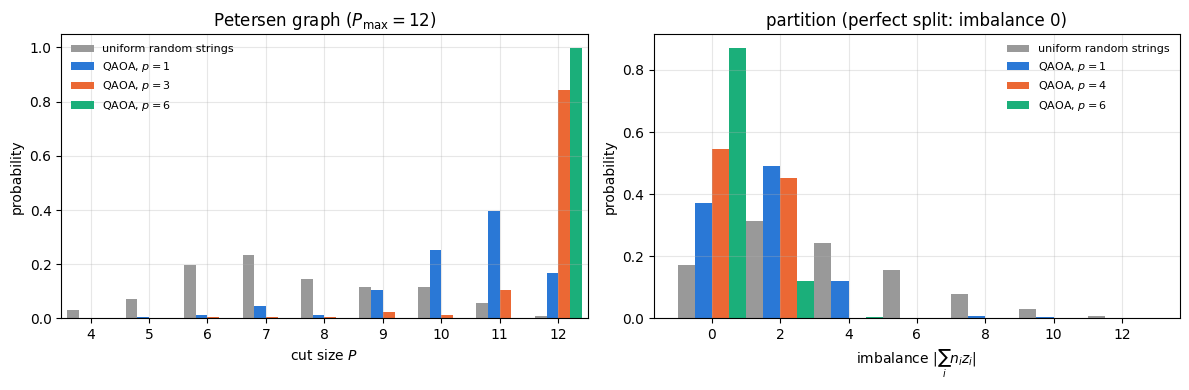

In [19]:
# ==============================================================================
# STEP 15: distribution of the cut size and the most probable strings
# ==============================================================================
inst = INSTANCES["Petersen"]
n_edges = len(inst["couplings"])
cut_of_string = ((n_edges - np.asarray(inst["diag"]).reshape(-1)) / 2).round().astype(int)    # Eq. (6)
cuts = np.arange(n_edges + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
uniform = np.bincount(cut_of_string, minlength=n_edges + 1) / 2 ** 10
ax1.bar(cuts - 0.3, uniform, width=0.2, color="0.6", label="uniform random strings")
for c, p in enumerate([1, 3, 6]):
    probs = np.abs(np.asarray(qaoa_state(jnp.asarray(RESULTS["Petersen"]["params_interp"][p - 1]), inst["diag"]))) ** 2
    dist = np.bincount(cut_of_string, weights=probs.reshape(-1), minlength=n_edges + 1)
    ax1.bar(cuts - 0.1 + 0.2 * c, dist, width=0.2, color=PALETTE[c], label=f"QAOA, $p={p}$")
    print(f"Petersen, p = {p}: <P> = {dist @ cuts:.3f},  Prob(P = 12) = {dist[12]:.4f},  Prob(P >= 11) = {dist[11:].sum():.4f}")
    z2_err = np.max(np.abs(probs - probs[tuple([slice(None, None, -1)] * 10)]))       # Prob(z) - Prob(flipped z)
    print(f"{'':18s}max |Prob(z) - Prob(all bits flipped)| = {z2_err:.1e}")
    assert z2_err < TOL
print(f"Petersen, uniform: <P> = {uniform @ cuts:.3f},  Prob(P = 12) = {uniform[12]:.4f}")
ax1.set_xlabel("cut size $P$")
ax1.set_ylabel("probability")
ax1.set_title("Petersen graph ($P_{\\max}=12$)")
ax1.set_xlim(3.5, 12.5)
ax1.legend(fontsize=8)

inst_np = INSTANCES["partition"]
flat_np = np.asarray(inst_np["diag"]).reshape(-1)
imbalance = np.sqrt(np.maximum(flat_np + 20.0, 0)).round().astype(int)          # |sum_i n_i z_i| from Eq. (7)
levels = np.arange(0, 13, 2)
uniform_np = np.array([np.mean(imbalance == d) for d in levels])
ax2.bar(levels - 0.75, uniform_np, width=0.5, color="0.6", label="uniform random strings")
for c, p in enumerate([1, 4, 6]):
    probs = np.abs(np.asarray(qaoa_state(jnp.asarray(RESULTS["partition"]["params_interp"][p - 1]), inst_np["diag"]))).reshape(-1) ** 2
    dist = np.array([probs[imbalance == d].sum() for d in levels])
    ax2.bar(levels - 0.25 + 0.5 * c, dist, width=0.5, color=PALETTE[c], label=f"QAOA, $p={p}$")
    top = np.sort(probs[imbalance == 0])[::-1]
    print(f"partition, p = {p}: Prob(imbalance 0, 2, 4) = {np.round(dist[:3], 4)};  the 44 optimal strings have "
          f"probabilities between {top[-1]:.4f} and {top[0]:.4f}")
print(f"partition, uniform: Prob(imbalance 0, 2, 4) = {np.round(uniform_np[:3], 4)}")
ax2.set_xlabel(r"imbalance $|\sum_i n_i z_i|$")
ax2.set_ylabel("probability")
ax2.set_title("partition (perfect split: imbalance 0)")
ax2.set_xticks(levels)
ax2.legend(fontsize=8)
fig.tight_layout()
plt.show()

On the Petersen graph a depth-one circuit shifts the cut distribution from the uniform one (mean $7.5$) to a mean of
$10.39$, with $57\,\%$ of the weight on cuts of size 11 or 12, but the optimal cut $P=12$ still has probability $0.17$. At
$p=3$ the optimum carries $0.84$ and at $p=6$ $0.998$. A string and its mirror image have exactly equal probabilities
in all three states, as the spin-flip symmetry of Section 4.3 requires.

For the partition instance the depth-one state already doubles the weight of perfect splits relative to random strings
($0.37$ against $0.17$) and puts most of the rest on imbalance 2. At $p=4$ the weight is shared almost evenly between
perfect splits ($0.55$) and imbalance 2 ($0.45$), and only at $p=6$ do the perfect splits dominate ($0.87$). The weight on
the optimum is spread over all 44 optimal strings with nearly equal probabilities (between $0.012$ and $0.014$ at
$p=4$), so even a large $p_{\rm opt}$ does not single out one string.

### 11.2 Shots, and the comparison with classical baselines

If a circuit gives an optimal string with probability $p_{\rm opt}$ per shot, the probability of seeing at least one
in $M$ shots is $1-(1-p_{\rm opt})^M$, and $M_{99}=\lceil\ln0.01/\ln(1-p_{\rm opt})\rceil$ shots give $99\,\%$
confidence. The cell draws 1000 shots from the $p=3$ state on the Petersen graph with the engine's
`sample_bitstrings`, compares the observed frequency of optimal strings with $p_{\rm opt}$, and tabulates $M_{99}$
for QAOA, random guessing and greedy descent from a random start.

In [20]:
# ==============================================================================
# STEP 16: sampling the p = 3 Petersen state; shots needed for 99% confidence
# ==============================================================================
SHOTS = 1000
psi3 = qaoa_state(jnp.asarray(RESULTS["Petersen"]["params_interp"][2]), inst["diag"])
bits = np.asarray(sample_bitstrings(jax.random.PRNGKey(7), psi3, SHOTS))
idx = bits @ (1 << np.arange(9, -1, -1))
sampled_cuts = cut_of_string[idx]
f_hat = float(np.mean(sampled_cuts == 12))
p_exact = RESULTS["Petersen"]["p_interp"][2]
se = np.sqrt(p_exact * (1 - p_exact) / SHOTS)
print(f"p = 3: fraction of optimal cuts in {SHOTS} shots = {f_hat:.3f}; exact p_opt = {p_exact:.4f}; "
      f"difference = {(f_hat - p_exact) / se:+.2f} standard errors")
print(f"       mean sampled cut = {sampled_cuts.mean():.3f};  best sampled cut = {sampled_cuts.max()}")
assert abs(f_hat - p_exact) < 4 * se


def shots_99(p):
    """Shots needed to see an optimal string at least once with probability 0.99."""
    return int(np.ceil(np.log(0.01) / np.log1p(-p))) if p < 1 else 1


print(f"\n{'instance':9s} | {'random':>8s} {'greedy':>8s} | " + " ".join(f"{'QAOA p=' + str(p):>9s}" for p in ps))
for name, inst_ in INSTANCES.items():
    p_rand = inst_["n_opt"] / 2 ** inst_["N"]
    row = " ".join(f"{shots_99(x):9d}" for x in RESULTS[name]["p_interp"])
    print(f"{name:9s} | {shots_99(p_rand):8d} {shots_99(inst_['p_greedy']):8d} | {row}")

p = 3: fraction of optimal cuts in 1000 shots = 0.855; exact p_opt = 0.8438; difference = +0.97 standard errors
       mean sampled cut = 11.763;  best sampled cut = 12

instance  |   random   greedy |  QAOA p=1  QAOA p=2  QAOA p=3  QAOA p=4  QAOA p=5  QAOA p=6
ring      |      588       12 |        29        11         6         1         1         1
cube      |      588        3 |        23         7         3         2         1         1
Petersen  |      470        1 |        25         8         3         2         2         1
partition |       25        1 |        10         8         6         6         3         3


The empirical frequency of optimal cuts, $0.855$ in 1000 shots, agrees with the exact $p_{\rm opt}=0.844$ within one
binomial standard error, and the best sampled cut is the optimum. The table puts the numbers in proportion. Random
guessing needs 470 to 588 shots on the MaxCut instances and 25 on the partition. Greedy descent from random starts
needs one start on the Petersen graph and on the partition, three on the cube and twelve on the ring. QAOA needs 23 to
29 shots at $p=1$ on the MaxCut instances and 10 on the partition, more than greedy descent needs on every instance.
From $p=4$ on it needs one or two shots on the MaxCut instances and three to six on the partition. A greedy descent
tests $N$ flips per step and, on an unweighted graph, lowers the cost at most $\vert E\vert$ times, so one start costs
a number of classical operations polynomial in $N$; no instance in this notebook shows an advantage of QAOA over this
simple heuristic. The value of these small instances is that every number
can be checked; the open question of a practical advantage concerns sizes that cannot be simulated.

## 12. Cost of the simulation

The cell measures the compile time and run time of the energy and of its gradient on the Petersen graph ($N=10$) for
$p=1$ and $p=4$, and compares the phase implementation of the cost layer with the gate-by-gate circuit
(`qaoa_state_gates`), whose $\vert E\vert=15$ two-qubit gates per layer are unrolled by the Python loop. Run times are
medians of five calls of the compiled function.

In [21]:
# ==============================================================================
# STEP 17: compile and run times, phase versus gates
# ==============================================================================
inst = INSTANCES["Petersen"]
diag_P, coup_P = inst["diag"], inst["couplings"]
energy_gates = lambda t: jnp.sum(jnp.abs(qaoa_state_gates(t, 10, coup_P)) ** 2 * diag_P)
energy_phase = lambda t: qaoa_energy(t, diag_P)
print(f"{'p':>2s} {'implementation':>15s} | {'compile E':>10s} {'run E':>10s} | {'compile grad':>12s} {'run grad':>10s}")
for p in (1, 4):
    t = jnp.linspace(0.1, 0.6, 2 * p)
    for label, fn in [("phase + scan", energy_phase), ("gates, unrolled", energy_gates)]:
        cE, tcE = compile_timed(fn, t)
        _, trE = run_timed(cE, t)
        cG, tcG = compile_timed(jax.grad(fn), t)
        _, trG = run_timed(cG, t)
        print(f"{p:2d} {label:>15s} | {tcE:9.3f}s {trE * 1e3:8.3f}ms | {tcG:11.3f}s {trG * 1e3:8.3f}ms")
    assert abs(float(energy_gates(t) - energy_phase(t))) < TOL * 100

 p  implementation |  compile E      run E | compile grad   run grad


 1    phase + scan |     0.105s    0.236ms |       0.245s    0.445ms


 1 gates, unrolled |     0.209s    0.269ms |       0.640s    0.460ms


 4    phase + scan |     0.112s    0.292ms |       0.380s    1.232ms


 4 gates, unrolled |     0.481s    0.637ms |       2.764s    1.541ms


Both implementations give the same energy. The compile time of the phase implementation grows only mildly with $p$,
because `lax.scan` traces one layer, and a layer costs one multiplication plus $N$ rotations whatever the number of
couplings. The unrolled circuit traces every gate of every layer, and the compilation of its gradient grows with
$p\,\vert E\vert$ and reaches a few seconds at $p=4$ in the table. Run times of both versions lie between about a tenth
of a millisecond and a few milliseconds per energy or gradient, and they fluctuate from run to run on a shared machine. The training of Section 8
consists of about $5\times10^4$ gradient evaluations ($4\times6\times300$ for INTERP and $2\times6\times12\times300$
for the restarts), and its run time is printed with the table there. The memory needed is one state of $2^N$ complex
numbers plus the diagonal, 16 kB and 8 kB at $N=10$.

## 13. Key takeaways

* **A binary optimisation problem is a diagonal Hamiltonian.** The substitution $s=(1-z)/2$ turns any QUBO into an
  Ising Hamiltonian, Eq. (3), checked on every string of a random instance. MaxCut gives $H_C=\sum_{(i,j)\in E}Z_iZ_j$,
  number partitioning a complete graph with $J_{ij}=2n_in_j$. In simulation the cost is one tensor of $2^N$ numbers,
  and the cost layer is an element-wise phase, identical to the gate-by-gate circuit to round-off.
* **Symmetries fix the search region.** The spin-flip symmetry gives period $\pi/2$ in every $\beta_l$ and equal
  probabilities for a string and its mirror image, the integer spectrum gives period $\pi$ (MaxCut) or $\pi/2$ (the
  partition instance) in every $\gamma_l$, and time reversal gives
  $E(-\boldsymbol\gamma,-\boldsymbol\beta)=E(\boldsymbol\gamma,\boldsymbol\beta)$.
* **Depth one is solvable on paper.** Eq. (16) gives $E_1$ for any unweighted graph and matches the simulation to
  round-off; without its triangle term it fails, by $1.2$, exactly on the graph with triangles. On triangle-free
  $D$-regular graphs the optimal angles depend only on $D$, with $r_1=3/4$ on even rings and an edge fraction
  $0.69245$ for $D=3$.
* **The exact gradient of a layer angle is set by its frequencies.** The two-term shift of a single Pauli rotation,
  applied to a whole layer, gave wrong $\gamma$-components and identically zero $\beta$-components; the gate-level
  rule with the chain rule, $2p(\vert E\vert+N)$ evaluations, agreed with automatic differentiation to $10^{-13}$. The
  landscape along one angle contains harmonics up to the spread of the generator's spectrum, fewer where the light
  cone is small; the last mixer angle has a single frequency and an exact two-term rule with shift $\pi/8$.
* **Depth helps, and interpolation finds good optima.** The ring follows $(2p+1)/(2p+2)$ until its light cone closes
  at $p=4$, where $r=1$. The cube and the Petersen graph reach $r>0.99$ by $p=5$ and $p_{\rm opt}>0.97$ from $p=4$.
  INTERP, one run per depth, agreed with the best of 12 random starts on the Petersen graph to within $0.0015$ at every
  depth; on the partition instance it followed a branch of local optima that a random start beat at $p=4$.
* **The optimal schedule resembles annealing and needs fewer layers.** The optimal $\gamma_l$ rise and
  $\vert\beta_l\vert$ fall on the 3-regular graphs, with the signs of Trotterised annealing, Eq. (21). The linear
  schedule also converges to the optimum but needed 16 layers to match the optimised $p=4$ circuit; reversing its sign
  drives the system to the top of the spectrum.
* **Angles transfer well at depth one and less well beyond.** Angles optimised on the Petersen graph lost at most
  $0.008$ in the score on six random 3-regular graphs at $p=1$, and up to $0.10$ at $p=3$.
* **Low expected cost is not the same as a likely optimum.** At $p=4$ the partition and cube states have nearly equal
  scores and $p_{\rm opt}=0.55$ against $0.97$. Sampling reproduced $p_{\rm opt}$ within the binomial error.
* **No advantage at this size.** Greedy single-flip descent from a random string solved the Petersen and partition
  instances every time, the cube in $89\,\%$ and the ring in $33\,\%$ of the starts (ties to the lowest index). These instances serve as test
  beds on which every number can be checked.

## 14. Exercises

1. ★ **Odd rings.** For a ring with odd $N$, $P_{\max}=N-1$. Use Eq. (17) to predict $r_1$ for $N=5,7,9$, and check
   with `landscape_p1`. Then run the INTERP chain of Section 8 on $N=9$ and compare $r_p$ with
   $(2p+1)N/\big((2p+2)(N-1)\big)$ for $p<4$.
2. ★ **The light cone.** At depth $p$ the expectation value $\langle Z_uZ_v\rangle$ of a ring edge depends only on the
   $2p+2$ spins nearest to it. Verify this by computing $\langle Z_0Z_1\rangle$ at the INTERP angles of the $N=8$ ring
   for $p=1,2,3$, and the same quantity on an *open* chain of $2p+2$ spins with the edge in the middle, using the same
   angles.
3. ★★ **Weighted MaxCut (extend the code).** Repeat the derivation of Section 5.1 for edge weights $J_{uv}$, where the
   cost factors become $e^{-i\gamma J_{uw}Z_uZ_w}$. Show that $\cos^{d_u-1}2\gamma$ is replaced by a product of
   $\cos2\gamma J_{uw}$ over the other neighbours, implement the result, and check it on the Petersen graph with random
   weights.
4. ★★ **A general shift rule.** Section 7 counted the harmonics of $E(\beta_1)$. Write $E(\beta_1)$ as a trigonometric
   polynomial with only those frequencies, determine its coefficients from that many evaluations at equally spaced
   angles, and differentiate it analytically. Compare the number of circuit evaluations and the accuracy with the
   gate-level rule.
5. ★★ **Train on the probability of the optimum.** Replace the cost $E_p$ by $-\log p_{\rm opt}$ (which needs the
   knowledge of the optimal strings and is therefore only a diagnostic) on the partition instance. How
   far can $p_{\rm opt}$ be pushed at $p=2,3,4$ compared with the energy-optimised circuits, and what happens to the
   score $r_p$?
6. ★★ **A partition without a perfect split (physics).** Take the numbers $\{3,1,1,2,2,1,5,4\}$ (sum 19, odd). Compute
   $E_{\min}$ and the number of optimal strings, the depth-one landscape and the INTERP chain. Which period in $\gamma$
   does Section 4.3 predict now?
7. ★★★ **The minimum gap and the annealing time (physics).** For the Petersen graph, compute the two lowest
   eigenvalues of $H(s)$ in the spin-flip-symmetric sector for $s\in[0,1]$, with the engine's `lanczos_ground_state`
   on the symmetrised problem or with dense diagonalisation at $N=10$. Locate the minimum gap $\Delta_{\min}$ and
   compare the total time $T=p\,\Delta t$ at which the linear schedule of Section 9 reaches $r=0.99$ with
   $1/\Delta_{\min}^2$.
8. ★★★ **Transfer across sizes.** Optimise INTERP angles up to $p=4$ on a random 3-regular graph with $N=6$ and $N=8$
   and apply them to the graphs of Section 10. Does the transferred score improve with the size of the source graph?

## References

* E. Farhi, J. Goldstone and S. Gutmann, *A quantum approximate optimization algorithm*, arXiv:1411.4028 (2014) — the
  algorithm of Eq. (9), the $(2p+1)/(2p+2)$ values on the ring, and the bound $0.6924$ at $p=1$ on 3-regular graphs.
* E. Farhi, J. Goldstone, S. Gutmann and M. Sipser, *Quantum computation by adiabatic evolution*,
  arXiv:quant-ph/0001106 (2000) — the adiabatic algorithm of Sections 1.1 and 9.
* T. Kadowaki and H. Nishimori, *Quantum annealing in the transverse Ising model*, Phys. Rev. E **58**, 5355 (1998)
  — quantum annealing with a time-dependent transverse field in the role of the temperature (Section 1.1).
* J. Preskill, *Quantum computing in the NISQ era and beyond*, Quantum **2**, 79 (2018) — noisy intermediate-scale
  quantum devices (Section 1.1).
* S. Bravyi, A. Kliesch, R. Koenig and E. Tang, *Obstacles to variational quantum optimization from symmetry
  protection*, Phys. Rev. Lett. **125**, 260505 (2020) — locality and spin-flip symmetry limit QAOA at fixed depth on
  certain MaxCut instances (Section 1.1).
* M. P. Harrigan *et al.*, *Quantum approximate optimization of non-planar graph problems on a planar
  superconducting processor*, Nat. Phys. **17**, 332 (2021) — QAOA on up to 23 qubits of the Sycamore processor
  (Section 1.1).
* F. Barahona, M. Grötschel, M. Jünger and G. Reinelt, *An application of combinatorial optimization to statistical
  physics and circuit layout design*, Oper. Res. **36**, 493 (1988) — spin-glass ground states and via minimisation in
  circuit layout reduced to MaxCut (Section 3.2).
* A. Lucas, *Ising formulations of many NP problems*, Front. Phys. **2**, 5 (2014) — Ising forms of number partitioning
  and many other NP-hard problems.
* Z. Wang, S. Hadfield, Z. Jiang and E. G. Rieffel, *Quantum approximate optimization algorithm for MaxCut: A
  fermionic view*, Phys. Rev. A **97**, 022304 (2018) — the depth-one expectation value for a general graph, Eq. (16).
* L. Zhou, S.-T. Wang, S. Choi, H. Pichler and M. D. Lukin, *Quantum approximate optimization algorithm: Performance,
  mechanism, and implementation on near-term devices*, Phys. Rev. X **10**, 021067 (2020) — the INTERP initialisation
  of Eq. (20), the smooth shape of optimal schedules, and the comparison with annealing.
* G. B. Mbeng, R. Fazio and G. E. Santoro, *Quantum annealing: a journey through digitalization, control, and hybrid
  quantum variational schemes*, arXiv:1906.08948 (2019) — the bound $1/(2p+2)$ on the residual energy of the ring.
* F. G. S. L. Brandão, M. Broughton, E. Farhi, S. Gutmann and H. Neven, *For fixed control parameters the quantum
  approximate optimization algorithm's objective function value concentrates for typical instances*,
  arXiv:1812.04170 (2018) — concentration and transfer of angles, Section 10.
* D. Wierichs, J. Izaac, C. Wang and C. Y.-Y. Lin, *General parameter-shift rules for quantum gradients*, Quantum
  **6**, 677 (2022) — shift rules for generators with many eigenvalues, with QAOA as an example.
* S. Hadfield, Z. Wang, B. O'Gorman, E. G. Rieffel, D. Venturelli and R. Biswas, *From the quantum approximate
  optimization algorithm to a quantum alternating operator ansatz*, Algorithms **12**, 34 (2019) — generalisations of
  the mixer, e.g. for constrained problems (Section 3.1).
* D. P. Kingma and J. Ba, *Adam: A method for stochastic optimization*, arXiv:1412.6980 (2014) — the optimiser of
  Section 8.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/